# Cross-season comparison: Rank vs Percentage (fan vs judge)

This notebook loads the pooled fan-vote model from `model.py`, computes week-level fan shares, and compares **rank-rule** vs **percent-rule** eliminations across seasons. It also quantifies disagreement and fan-override metrics.

In [107]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import model

sns.set_theme(style="whitegrid", font_scale=1.0)
SEED = 42
np.random.seed(SEED)


In [108]:
# --- Load data and build panel ---
df_elim_events, df_roster, df_weekly, df_long_judge, df_clean = model.load_tables()

elim_long = model.build_elim_long(df_elim_events)
base = model.build_base(df_roster, elim_long, df_clean)
judge_percent = model.build_judge_percent(df_weekly, base)
judge_rank_share = model.build_judge_rank_share(df_long_judge, base)

panel = model.build_panel(base, judge_percent, judge_rank_share, era_cutoff=28)

# Train pooled model (fan share prior q_hat)
model_obj, pooled_fit, train_weeks = model.train_pooled_model(
    panel,
    seed=SEED,
    tau=0.05,
    l2_beta=0.05,
    l2_u=0.05,
    kappa=10.0,
    lr=0.020,
    n_steps=600,
    batch_size=32,
)
print("train weeks:", train_weeks.shape[0])


/Users/jerryli/Desktop/MCM/model.py:68: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  base["elim_this_week_end"] = base["elim_this_week_end"].fillna(False).astype(bool)


train weeks: 218


In [109]:
# --- Helper: build fan share p_hat per week ---
# preference: posterior mean if single-elim non-final week; fallback to q_hat

def build_week_fanshare(panel, pooled_fit, weeks_df, *, B=1200, tau_like=0.15):
    rows = []
    for s, wk in weeks_df[["season", "week"]].values.tolist():
        out = model.posterior_mean_for_week(
            panel, pooled_fit, int(s), int(wk),
            B=B, tau_like=tau_like,
            seed=SEED + int(s) * 1000 + int(wk)
        )
        if out is None:
            continue
        rows.append(out)
    post = pd.concat(rows, ignore_index=True)

    # if some weeks are missing (e.g., no single-elim), fall back to q_hat
    post_key = post[["season", "week", "celebrity_name"]]
    post_key["_has"] = True

    alive_all = panel[panel["alive"]==True][["season","week","celebrity_name","era","j_metric","elim_this_week_end"]].copy()
    alive_all = alive_all.merge(post_key, on=["season","week","celebrity_name"], how="left")

    # fill p_mean with q_hat for missing
    missing = alive_all["_has"].isna()
    if missing.any():
        q_hat = []
        for (s, wk), g in alive_all[missing].groupby(["season","week"]):
            gg = model.pooled_q_for_week(panel, pooled_fit, int(s), int(wk))
            q_hat.append(gg[["season","week","celebrity_name","q_hat"]])
        q_hat = pd.concat(q_hat, ignore_index=True)
        alive_all = alive_all.merge(q_hat, on=["season","week","celebrity_name"], how="left")
    else:
        alive_all["q_hat"] = np.nan

    # merge posterior mean where available
    alive_all = alive_all.merge(
        post[["season","week","celebrity_name","p_mean","q_hat","has_posterior"]],
        on=["season","week","celebrity_name"], how="left", suffixes=("","_post")
    )

    # choose p_hat
    alive_all["p_hat"] = alive_all["p_mean"]
    alive_all.loc[alive_all["p_hat"].isna(), "p_hat"] = alive_all.loc[alive_all["p_hat"].isna(), "q_hat"]

    return alive_all[["season","week","celebrity_name","era","j_metric","p_hat","elim_this_week_end"]]

# Eligible weeks: non-final + single-elim (same as training filter)
train_weeks_simple = train_weeks[["season","week"]].copy()
week_fanshare = build_week_fanshare(panel, pooled_fit, train_weeks_simple, B=1200, tau_like=0.15)
week_fanshare.head()


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_4927/22190440.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  post_key["_has"] = True


,season,week,celebrity_name,era,j_metric,p_hat,elim_this_week_end
0,1,1,Evander Holyfield,rank,0.009929,0.184031,False
1,1,2,Evander Holyfield,rank,0.000001,0.161945,False
2,1,3,Evander Holyfield,rank,0.000016,0.089944,True
3,1,1,Joey McIntyre,rank,0.328801,0.128127,False
4,1,2,Joey McIntyre,rank,0.003585,0.371702,False


In [110]:
# --- Step 1: unified rules (rank vs percent) ---
# Inputs per (season,week): T_i (judge total score) and p_hat (fan share)

# pick judge score column
score_col = "total_judge_score" if "total_judge_score" in df_weekly.columns else "judge_total"

def compute_week_predictions(df_week, *, score_col):
    g = df_week.copy()
    # ranks (lower rank = better)
    g["rJ"] = g[score_col].rank(ascending=False, method="average")
    g["rF"] = g["p_hat"].rank(ascending=False, method="average")

    # rank rule
    g["R_rank"] = g["rJ"] + g["rF"]
    elim_rank = g.sort_values("R_rank", ascending=False).iloc[0]["celebrity_name"]

    # percent rule
    denom = g[score_col].sum()
    g["J_pct"] = g[score_col] / denom if denom != 0 else 0.0
    g["S_pct"] = g["J_pct"] + g["p_hat"]
    elim_pct = g.sort_values("S_pct", ascending=True).iloc[0]["celebrity_name"]

    # judge-worst (for override)
    judge_worst = g.sort_values(score_col, ascending=True).iloc[0]["celebrity_name"]

    # disagreement structure metrics
    judge_margin = g[score_col].max() - g[score_col].min()
    fan_entropy = -np.sum(np.clip(g["p_hat"].to_numpy(), 1e-12, 1.0) * np.log(np.clip(g["p_hat"].to_numpy(), 1e-12, 1.0)))
    # controversy strength: mean |rJ - rF|
    g["rank_gap"] = (g["rJ"] - g["rF"]).abs()
    controversy = g["rank_gap"].mean()

    out = {
        "season": int(g["season"].iloc[0]),
        "week": int(g["week"].iloc[0]),
        "era": g["era"].iloc[0],
        "alive_size": int(g.shape[0]),
        "eliminated_true": g.loc[g["elim_this_week_end"]==True, "celebrity_name"].iloc[0] if g["elim_this_week_end"].any() else None,
        "eliminated_rank": elim_rank,
        "eliminated_pct": elim_pct,
        "judge_worst": judge_worst,
        "judge_margin": float(judge_margin),
        "fan_entropy": float(fan_entropy),
        "controversy": float(controversy),
    }
    return out

# build weekly table
rows = []
for (s, wk), g in week_fanshare.merge(
        df_weekly[["season","week","celebrity_name", score_col]],
        on=["season","week","celebrity_name"], how="left"
    ).groupby(["season","week"]):
    rows.append(compute_week_predictions(g, score_col=score_col))

weekly = pd.DataFrame(rows)
weekly["agree_rank_pct"] = (weekly["eliminated_rank"] == weekly["eliminated_pct"]).astype(int)
weekly["agree_rank_true"] = (weekly["eliminated_rank"] == weekly["eliminated_true"]).astype(int)
weekly["agree_pct_true"] = (weekly["eliminated_pct"] == weekly["eliminated_true"]).astype(int)

weekly.head()


,season,week,era,alive_size,eliminated_true,eliminated_rank,eliminated_pct,judge_worst,judge_margin,fan_entropy,controversy,agree_rank_pct,agree_rank_true,agree_pct_true
0,1,1,rank,6,None,Trista Sutter,Rachel Hunter,Kelly Monaco,7.0,1.473216,2.500000,0,0,0
1,1,2,rank,6,Trista Sutter,Evander Holyfield,Trista Sutter,Evander Holyfield,12.0,1.361028,2.666667,0,0,1
2,1,3,rank,5,Evander Holyfield,Evander Holyfield,Evander Holyfield,Evander Holyfield,13.0,1.308810,2.000000,1,1,1
3,1,4,rank,4,Rachel Hunter,Joey McIntyre,Rachel Hunter,Joey McIntyre,6.0,0.885333,2.000000,0,0,1
4,1,5,rank,3,None,Joey McIntyre,John O'Hurley,Joey McIntyre,4.5,0.739107,1.333333,0,0,0


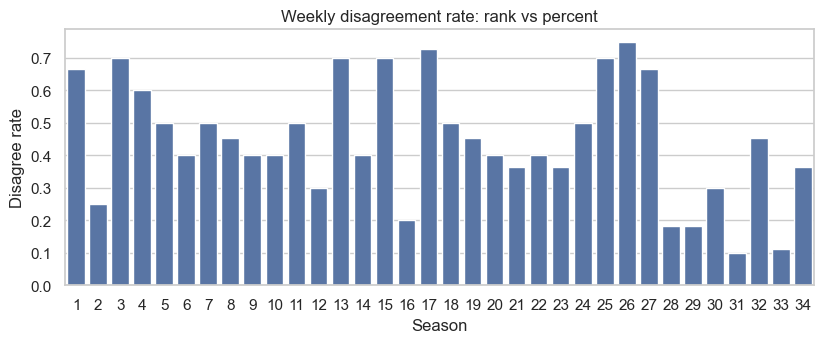

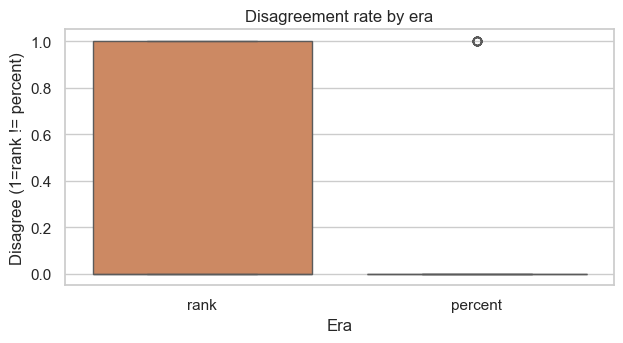

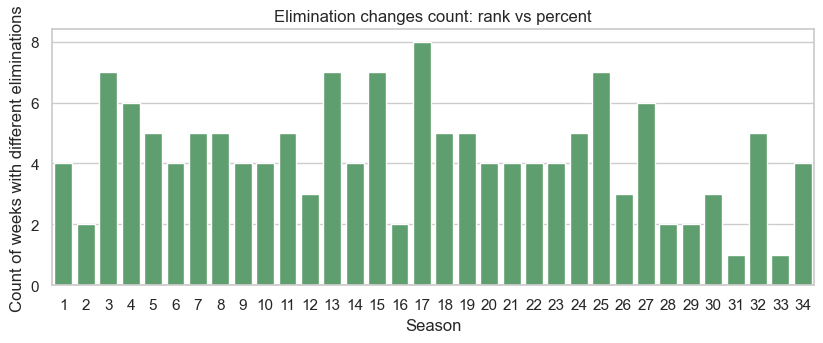

In [111]:
# --- Step 3.1: Disagreement rate by season / era ---
weekly["disagree"] = 1 - weekly["agree_rank_pct"]

season_disagree = (weekly.groupby("season")["disagree"]
                   .mean()
                   .reset_index(name="disagree_rate"))

plt.figure(figsize=(8.4,3.6))
sns.barplot(data=season_disagree, x="season", y="disagree_rate", color="#4C72B0")
plt.title("Weekly disagreement rate: rank vs percent")
plt.ylabel("Disagree rate")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.4,3.6))
sns.boxplot(data=weekly, x="era", y="disagree", color="#DD8452")
plt.title("Disagreement rate by era")
plt.ylabel("Disagree (1=rank != percent)")
plt.xlabel("Era")
plt.tight_layout()
plt.show()

# --- Added metric: elimination changes due to rule difference ---
weekly["elim_changed"] = weekly["disagree"].astype(int)

season_elim_changed = (weekly.groupby("season")["elim_changed"]
                       .sum()
                       .reset_index(name="elim_changed_count"))

plt.figure(figsize=(8.4,3.6))
sns.barplot(data=season_elim_changed, x="season", y="elim_changed_count", color="#55A868")
plt.title("Elimination changes count: rank vs percent")
plt.ylabel("Count of weeks with different eliminations")
plt.xlabel("Season")
plt.tight_layout()
plt.show()


/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_4927/3656943851.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  alive_disagree = (weekly.groupby(["alive_bin"])['disagree']


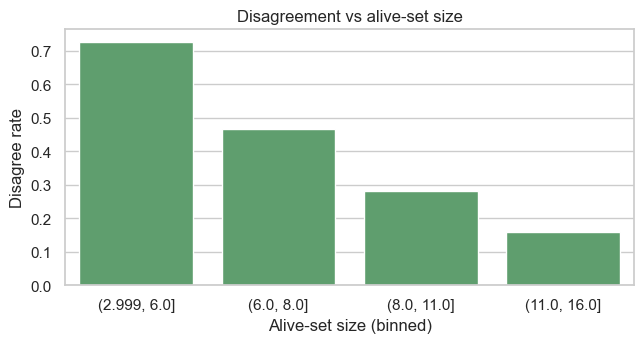

/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_4927/3656943851.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  margin_disagree = (weekly.groupby(["judge_margin_bin"])['disagree']


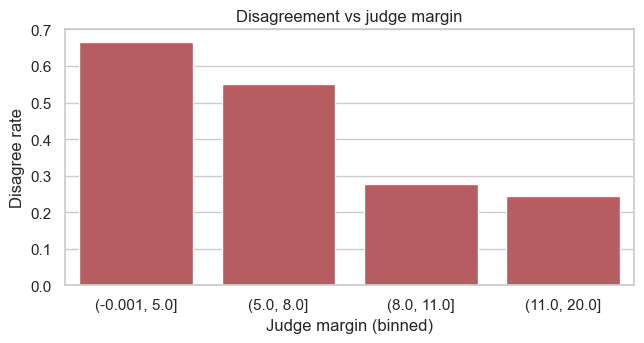

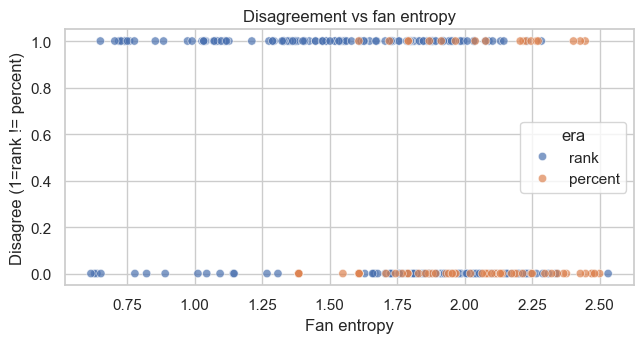

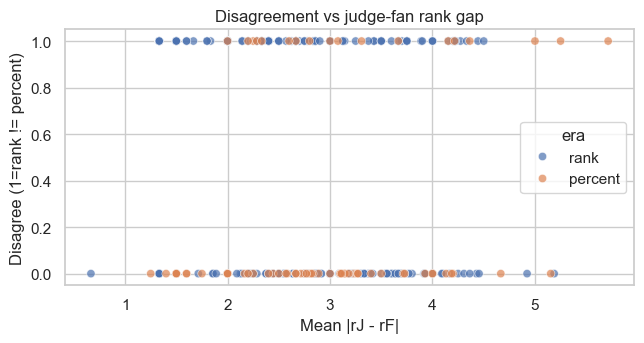

In [112]:
# --- Step 3.2: When do disagreements happen? ---
# Disagreement rate vs alive size (binned)
weekly["alive_bin"] = pd.qcut(weekly["alive_size"], q=4, duplicates="drop")

alive_disagree = (weekly.groupby(["alive_bin"])['disagree']
                  .mean()
                  .reset_index(name="disagree_rate"))

plt.figure(figsize=(6.6,3.6))
sns.barplot(data=alive_disagree, x="alive_bin", y="disagree_rate", color="#55A868")
plt.title("Disagreement vs alive-set size")
plt.xlabel("Alive-set size (binned)")
plt.ylabel("Disagree rate")
plt.tight_layout()
plt.show()

# Disagreement rate vs judge margin (binned)
weekly["judge_margin_bin"] = pd.qcut(weekly["judge_margin"], q=4, duplicates="drop")

margin_disagree = (weekly.groupby(["judge_margin_bin"])['disagree']
                   .mean()
                   .reset_index(name="disagree_rate"))

plt.figure(figsize=(6.6,3.6))
sns.barplot(data=margin_disagree, x="judge_margin_bin", y="disagree_rate", color="#C44E52")
plt.title("Disagreement vs judge margin")
plt.xlabel("Judge margin (binned)")
plt.ylabel("Disagree rate")
plt.tight_layout()
plt.show()

# Fan dispersion and controversy
plt.figure(figsize=(6.6,3.6))
sns.scatterplot(data=weekly, x="fan_entropy", y="disagree", hue="era", alpha=0.7)
plt.title("Disagreement vs fan entropy")
plt.xlabel("Fan entropy")
plt.ylabel("Disagree (1=rank != percent)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6.6,3.6))
sns.scatterplot(data=weekly, x="controversy", y="disagree", hue="era", alpha=0.7)
plt.title("Disagreement vs judge-fan rank gap")
plt.xlabel("Mean |rJ - rF|")
plt.ylabel("Disagree (1=rank != percent)")
plt.tight_layout()
plt.show()


In [113]:
# --- Step 4: Fan override rate (primary indicator) ---
weekly["override_rank"] = (weekly["eliminated_rank"] != weekly["judge_worst"]).astype(int)
weekly["override_pct"] = (weekly["eliminated_pct"] != weekly["judge_worst"]).astype(int)

season_override = (weekly.groupby("season")[["override_rank","override_pct"]].mean().reset_index())
season_override["delta_rank_minus_pct"] = season_override["override_rank"] - season_override["override_pct"]
season_override


,season,override_rank,override_pct,delta_rank_minus_pct
0,1,0.333333,0.833333,-0.500000
1,2,0.625000,0.875000,-0.250000
2,3,0.400000,0.800000,-0.400000
3,4,0.300000,0.900000,-0.600000
4,5,0.500000,0.700000,-0.200000
5,6,0.400000,0.600000,-0.200000
6,7,0.500000,0.800000,-0.300000
7,8,0.636364,0.818182,-0.181818
8,9,0.500000,0.900000,-0.400000
9,10,0.100000,0.500000,-0.400000


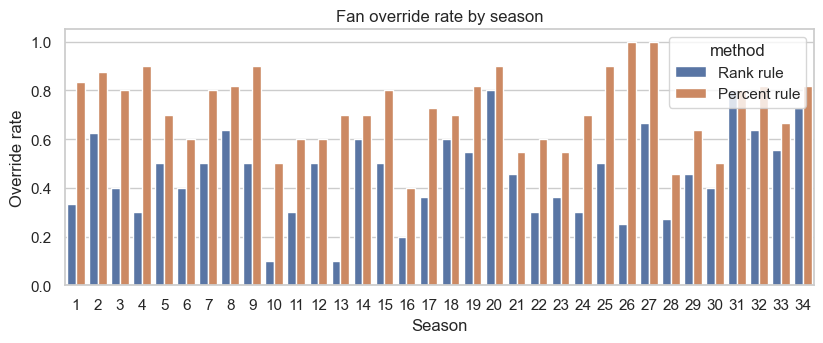

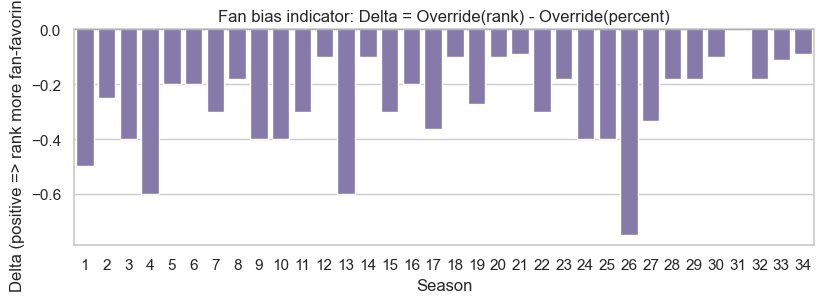

In [114]:
plt.figure(figsize=(8.4,3.6))
season_override_m = season_override.melt(id_vars="season", value_vars=["override_rank","override_pct"],
                                         var_name="method", value_name="override_rate")
season_override_m["method"] = season_override_m["method"].map({
    "override_rank": "Rank rule",
    "override_pct": "Percent rule",
})

sns.barplot(data=season_override_m, x="season", y="override_rate", hue="method")
plt.title("Fan override rate by season")
plt.ylabel("Override rate")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.4,3.2))
sns.barplot(data=season_override, x="season", y="delta_rank_minus_pct", color="#8172B2")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Fan bias indicator: Delta = Override(rank) - Override(percent)")
plt.ylabel("Delta (positive => rank more fan-favoring)")
plt.xlabel("Season")
plt.tight_layout()
plt.show()


In [115]:
# --- Step 5 (optional): posterior robustness via re-sampling ---
# For each week, sample fan shares and estimate P(rank == percent) and override differences.

import numpy as np

def posterior_draws_for_week(panel, pooled_fit, season, week, *, B=600, tau_like=0.15, seed=123):
    rng = np.random.default_rng(seed)
    g = model.pooled_q_for_week(panel, pooled_fit, int(season), int(week)).copy()
    n = g.shape[0]
    if n <= 1:
        return None

    if g["elim_this_week_end"].sum() == 1:
        elim_name = g.loc[g["elim_this_week_end"], "celebrity_name"].iloc[0]
        names = g["celebrity_name"].to_numpy()
        elim_pos = int(np.where(names == elim_name)[0][0])
    else:
        elim_pos = None

    q = g["q_hat"].to_numpy()
    alpha = pooled_fit["kappa"] * q
    p_samps = rng.dirichlet(alpha, size=B)

    if elim_pos is not None:
        j = g["j_metric"].to_numpy()
        cost = j[None, :] + p_samps
        logp = model.softmin_logprob_elim(cost, elim_pos, tau=tau_like)
        w = np.exp(logp - logp.max())
        w = w / w.sum()
    else:
        w = np.ones(B) / B

    return g, p_samps, w

# compute weekly probabilities
prob_rows = []
for s, wk in train_weeks[["season","week"]].values.tolist():
    out = posterior_draws_for_week(panel, pooled_fit, int(s), int(wk), B=600, tau_like=0.15,
                                   seed=SEED + int(s)*1000 + int(wk))
    if out is None:
        continue
    g, p_samps, w = out

    # judge scores
    score_col = "total_judge_score" if "total_judge_score" in df_weekly.columns else "judge_total"
    g = g.merge(df_weekly[["season","week","celebrity_name", score_col]],
                on=["season","week","celebrity_name"], how="left")
    T = g[score_col].to_numpy()

    # precompute judge ranks once
    rJ = pd.Series(T).rank(ascending=False, method="average").to_numpy()

    agree = 0.0
    override_rank = 0.0
    override_pct = 0.0
    for b in range(p_samps.shape[0]):
        p = p_samps[b]
        # rank rule
        rF = pd.Series(p).rank(ascending=False, method="average").to_numpy()
        R_rank = rJ + rF
        elim_rank = int(np.argmax(R_rank))

        # percent rule
        J_pct = T / T.sum() if T.sum() != 0 else np.zeros_like(T)
        S_pct = J_pct + p
        elim_pct = int(np.argmin(S_pct))

        agree += w[b] * (elim_rank == elim_pct)

        judge_worst = int(np.argmin(T))
        override_rank += w[b] * (elim_rank != judge_worst)
        override_pct += w[b] * (elim_pct != judge_worst)

    prob_rows.append({
        "season": int(s),
        "week": int(wk),
        "era": g["era"].iloc[0],
        "P_agree": float(agree),
        "P_override_rank": float(override_rank),
        "P_override_pct": float(override_pct),
    })

prob_week = pd.DataFrame(prob_rows)
prob_week.head()


,season,week,era,P_agree,P_override_rank,P_override_pct
0,1,2,rank,0.415791,0.232125,0.773876
1,1,3,rank,0.738771,0.015152,0.260369
2,1,4,rank,0.203872,0.208736,0.998352
3,2,1,rank,0.875521,0.896183,0.799744
4,2,2,rank,0.791397,0.688802,0.823241


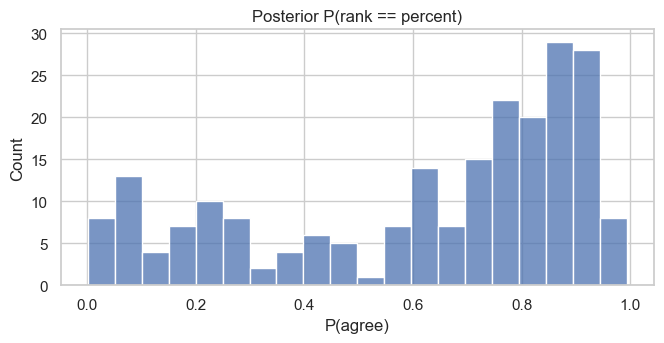

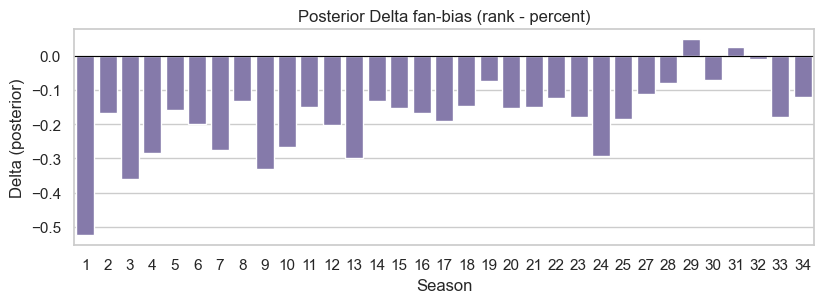

In [116]:
# Posterior stability plots (optional)
plt.figure(figsize=(6.8,3.6))
sns.histplot(data=prob_week, x="P_agree", bins=20, color="#4C72B0")
plt.title("Posterior P(rank == percent)")
plt.xlabel("P(agree)")
plt.tight_layout()
plt.show()

# season-level posterior override difference
prob_season = (prob_week.groupby("season")[["P_override_rank","P_override_pct"]].mean().reset_index())
prob_season["delta_rank_minus_pct"] = prob_season["P_override_rank"] - prob_season["P_override_pct"]

plt.figure(figsize=(8.4,3.2))
sns.barplot(data=prob_season, x="season", y="delta_rank_minus_pct", color="#8172B2")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Posterior Delta fan-bias (rank - percent)")
plt.ylabel("Delta (posterior)")
plt.xlabel("Season")
plt.tight_layout()
plt.show()


## Additions: Fan-favoring contrast, disagreement model, and uncertainty intervals

/var/folders/1q/v465hb014m30111mh0rv30rh0000gn/T/ipykernel_4927/1114044340.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fan_worst = (week_fanshare.groupby(["season","week"])             .apply(lambda g: g.sort_values("p_hat", ascending=True).iloc[0]["celebrity_name"])             .reset_index(name="fan_worst"))


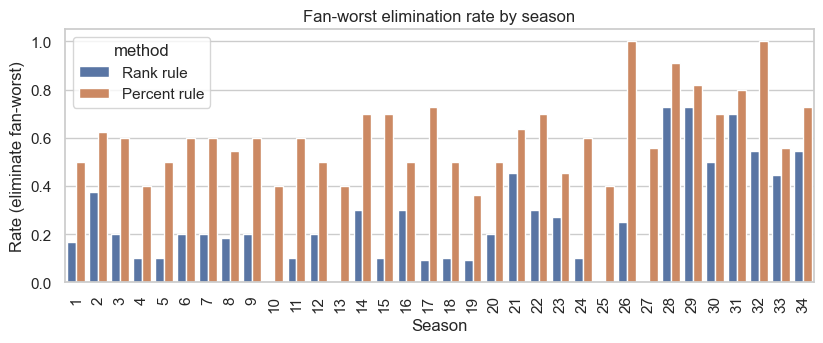

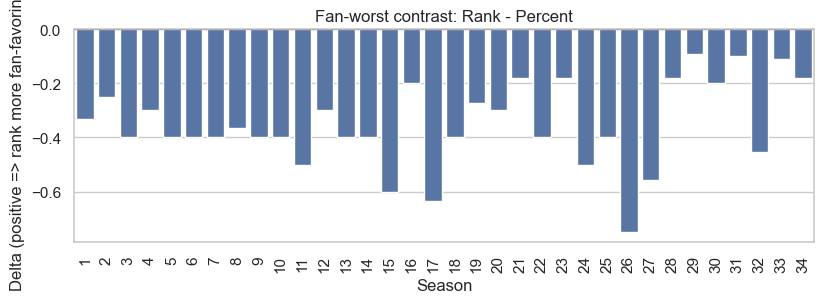

In [117]:
# A1) Fan-worst elimination rate (direct fan-favoring contrast)
# fan-worst = argmin p_hat within week

weekly = weekly.copy()

# identify fan-worst per week
fan_worst = (week_fanshare.groupby(["season","week"])             .apply(lambda g: g.sort_values("p_hat", ascending=True).iloc[0]["celebrity_name"])             .reset_index(name="fan_worst"))

weekly = weekly.merge(fan_worst, on=["season","week"], how="left")
weekly["fanworst_rank"] = (weekly["eliminated_rank"] == weekly["fan_worst"]).astype(int)
weekly["fanworst_pct"] = (weekly["eliminated_pct"] == weekly["fan_worst"]).astype(int)

season_fanworst = (weekly.groupby("season")[["fanworst_rank","fanworst_pct"]]
                   .mean().reset_index())
season_fanworst["delta_fanworst_rank_minus_pct"] = season_fanworst["fanworst_rank"] - season_fanworst["fanworst_pct"]

# plot
plt.figure(figsize=(8.4,3.6))
season_fanworst_m = season_fanworst.melt(id_vars="season", value_vars=["fanworst_rank","fanworst_pct"],
                                         var_name="method", value_name="rate")
season_fanworst_m["method"] = season_fanworst_m["method"].map({
    "fanworst_rank": "Rank rule",
    "fanworst_pct": "Percent rule",
})

sns.barplot(data=season_fanworst_m, x="season", y="rate", hue="method")
plt.title("Fan-worst elimination rate by season")
plt.ylabel("Rate (eliminate fan-worst)")
plt.xlabel("Season")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8.4,3.2))
sns.barplot(data=season_fanworst, x="season", y="delta_fanworst_rank_minus_pct", color="#4C72B0")
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Fan-worst contrast: Rank - Percent")
plt.ylabel("Delta (positive => rank more fan-favoring)")
plt.xlabel("Season")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


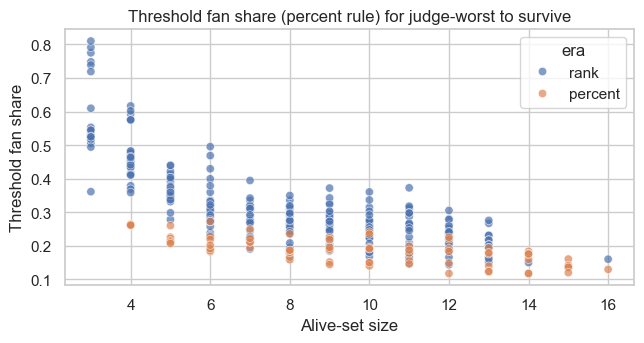

In [118]:
# A2) Fan share threshold for judge-worst to avoid elimination
# For percent rule: need p_j - p_k >= J_k - J_j for all k != j
# Threshold for judge-worst = max_k (p_k + J_k - J_j). Lower => more fan-favoring.

score_col = "total_judge_score" if "total_judge_score" in df_weekly.columns else "judge_total"

rows = []
for (s, wk), g in week_fanshare.merge(
        df_weekly[["season","week","celebrity_name", score_col]],
        on=["season","week","celebrity_name"], how="left"
    ).groupby(["season","week"]):
    g = g.copy()
    # judge-worst index
    j_idx = g[score_col].astype(float).idxmin()
    J = g[score_col].astype(float).to_numpy()
    p = g["p_hat"].to_numpy()
    J_pct = J / J.sum() if J.sum() != 0 else np.zeros_like(J)

    j = list(g.index).index(j_idx)
    # percent-rule threshold for judge-worst to avoid elimination
    thr_pct = np.max(p + J_pct - J_pct[j])

    rows.append({
        "season": int(g["season"].iloc[0]),
        "week": int(g["week"].iloc[0]),
        "era": g["era"].iloc[0],
        "thr_pct": float(thr_pct),
        "alive_size": int(g.shape[0])
    })

thr_df = pd.DataFrame(rows)

plt.figure(figsize=(6.6,3.6))
sns.scatterplot(data=thr_df, x="alive_size", y="thr_pct", hue="era", alpha=0.7)
plt.title("Threshold fan share (percent rule) for judge-worst to survive")
plt.xlabel("Alive-set size")
plt.ylabel("Threshold fan share")
plt.tight_layout()
plt.show()


In [119]:
# B) Logistic regression for disagreement drivers
import statsmodels.api as sm
import statsmodels.formula.api as smf

# prepare data
reg_df = weekly[["disagree","alive_size","judge_margin","fan_entropy","controversy","era","season"]].copy()
reg_df = reg_df.dropna()
reg_df["era"] = reg_df["era"].astype(str)

# standardize continuous predictors for stability
for col in ["alive_size","judge_margin","fan_entropy","controversy"]:
    reg_df[col] = (reg_df[col] - reg_df[col].mean()) / (reg_df[col].std(ddof=0) + 1e-12)

# logistic regression with season-clustered SE
model_logit = smf.glm(
    formula="disagree ~ alive_size + judge_margin + fan_entropy + controversy + C(era)",
    data=reg_df,
    family=sm.families.Binomial()
).fit(cov_type="cluster", cov_kwds={"groups": reg_df["season"]})

print(model_logit.summary())


                 Generalized Linear Model Regression Results                  
Dep. Variable:               disagree   No. Observations:                  332
Model:                            GLM   Df Residuals:                      326
Model Family:                Binomial   Df Model:                            5
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -173.98
Date:                Sun, 01 Feb 2026   Deviance:                       347.96
Time:                        11:48:57   Pearson chi2:                     372.
No. Iterations:                     5   Pseudo R-squ. (CS):             0.2775
Covariance Type:              cluster                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept         -1.1123      0.547     -2.

模型：disagree ~ era + alive_size + judge_margin + fan_entropy + controversy，并用了 cluster robust covariance（很对路）。

系数的含义（log-odds）：

alive_size 系数 -1.8948 (p=0.004)：alive 越大，disagree 概率显著下降。与你分箱图一致（人越少越容易分歧）。

controversy 系数 +1.1774 (p<0.001)：judge-fan rank gap 越大，分歧概率显著上升。这是“机制差异被冲突放大”的统计确认。

judge_margin -0.3071 (p≈0.059)：边缘显著，方向与你图一致：评委分差越大越不容易分歧。

fan_entropy 不显著：可能因为 entropy 对分歧的贡献小，或被 controversy/alive_size 吸收了。

era（rank era）正向但不显著：说明“时代差异”可能更多是通过 alive_size/controversy 等结构变量体现，而不是 era 本身。

这块你可以写一句很硬的结论：

在控制 era、fan dispersion 后，alive set 规模与 judge–fan 冲突程度仍显著解释了两种合并规则产生不同淘汰结果的概率。

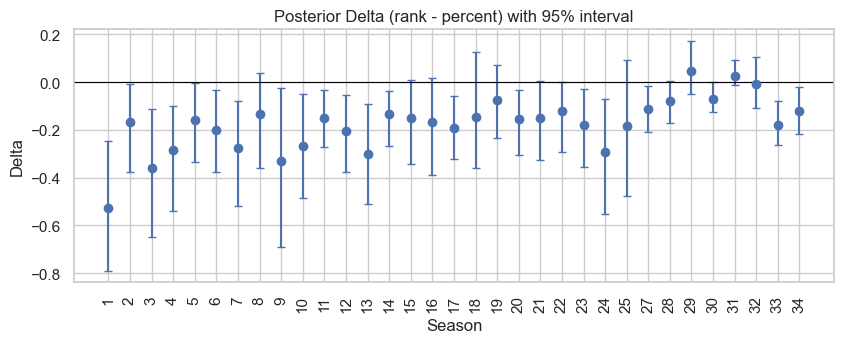

In [120]:
# C) Season-level Delta with 95% posterior interval (from prob_week)
# Uses prob_week from optional posterior sampling cell

if 'prob_week' in globals():
    prob_season = (prob_week.groupby("season")[["P_override_rank","P_override_pct"]].mean().reset_index())
    prob_season["delta"] = prob_season["P_override_rank"] - prob_season["P_override_pct"]

    # bootstrap season-level delta across weeks
    boot_rows = []
    rng = np.random.default_rng(42)
    for s, g in prob_week.groupby("season"):
        g = g.copy().reset_index(drop=True)
        n = len(g)
        if n < 2:
            continue
        deltas = []
        for _ in range(1000):
            samp = g.sample(n=n, replace=True, random_state=None)
            d = samp["P_override_rank"].mean() - samp["P_override_pct"].mean()
            deltas.append(d)
        lo, hi = np.quantile(deltas, [0.025, 0.975])
        boot_rows.append({"season": int(s), "delta": prob_season.loc[prob_season['season']==s, 'delta'].values[0],
                          "lo": float(lo), "hi": float(hi)})

    boot = pd.DataFrame(boot_rows)

    plt.figure(figsize=(8.6,3.6))
    plt.errorbar(x=boot["season"].astype(str), y=boot["delta"],
                 yerr=[boot["delta"]-boot["lo"], boot["hi"]-boot["delta"]],
                 fmt='o', color="#4C72B0", ecolor="#4C72B0", capsize=3)
    plt.axhline(0, color="black", linewidth=0.8)
    plt.title("Posterior Delta (rank - percent) with 95% interval")
    plt.xlabel("Season")
    plt.ylabel("Delta")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()
else:
    print("prob_week not found. Run the posterior sampling cell first.")


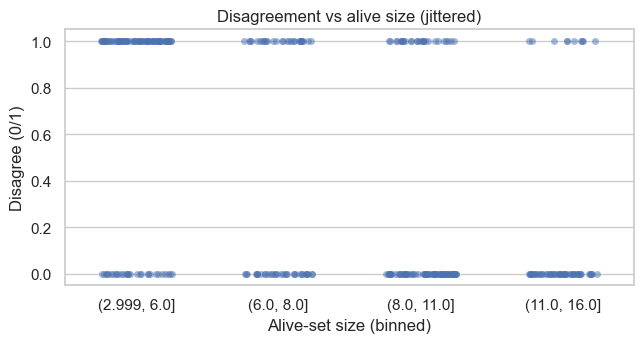

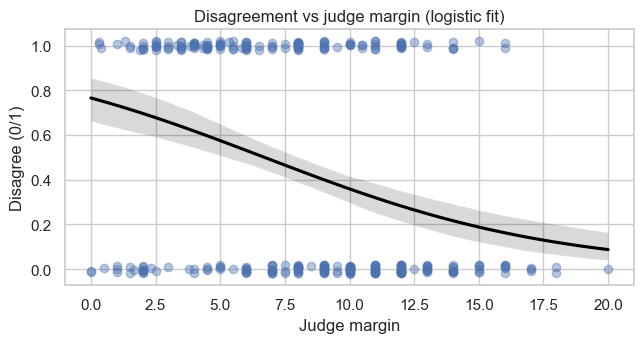

In [121]:
# E) Visualization tweaks: jitter / logistic fit

plt.figure(figsize=(6.6,3.6))
sns.stripplot(data=weekly, x="alive_bin", y="disagree", jitter=0.25, alpha=0.5)
plt.title("Disagreement vs alive size (jittered)")
plt.xlabel("Alive-set size (binned)")
plt.ylabel("Disagree (0/1)")
plt.tight_layout()
plt.show()

# logistic curve for a single predictor
plt.figure(figsize=(6.6,3.6))
sns.regplot(data=weekly, x="judge_margin", y="disagree", logistic=True, y_jitter=0.02,
            scatter_kws={"alpha":0.4}, line_kws={"color":"black"})
plt.title("Disagreement vs judge margin (logistic fit)")
plt.xlabel("Judge margin")
plt.ylabel("Disagree (0/1)")
plt.tight_layout()
plt.show()


## Judge–Fan Disagreement Index (rank & share)

Define per-week disagreement and aggregate to contestant-season level.


In [122]:
# --- Build week_base for disagreement index ---
# week_fanshare provides p_hat + era; merge judge scores for rJ and J_pct
week_base = week_fanshare.merge(
    df_weekly[["season", "week", "celebrity_name", score_col]],
    on=["season", "week", "celebrity_name"],
    how="left"
)


In [123]:
# --- Build per-week disagreement signals ---
week_df = week_base.copy()

# ranks (1 = best)
week_df['rJ'] = week_df.groupby(['season','week'])[score_col].rank(ascending=False, method='average')
week_df['rF'] = week_df.groupby(['season','week'])['p_hat'].rank(ascending=False, method='average')
week_df['delta_r'] = week_df['rF'] - week_df['rJ']

# judge share (within-week)
def _pct(x):
    s = x.sum()
    return x / s if s != 0 else x * 0.0

week_df['J_pct'] = week_df.groupby(['season','week'])[score_col].transform(_pct)
week_df['delta_s'] = week_df['p_hat'] - week_df['J_pct']

# aggregate to contestant-season
disagree_index = (
    week_df.groupby(['season','celebrity_name','era'])
    .agg(
        delta_r_bar=('delta_r','mean'),
        delta_s_bar=('delta_s','mean'),
        n_weeks=('week','nunique')
    )
    .reset_index()
)

disagree_index.head()


,season,celebrity_name,era,delta_r_bar,delta_s_bar,n_weeks
0,1,Evander Holyfield,rank,-2.166667,0.010813,3
1,1,Joey McIntyre,rank,-1.600000,0.150747,6
2,1,John O'Hurley,rank,1.800000,-0.067523,6
3,1,Kelly Monaco,rank,-1.400000,0.111120,6
4,1,Rachel Hunter,rank,2.750000,-0.193704,4


In [124]:
# --- Thresholds: Scheme A (quantile-based + persistence) ---
q = 0.90  # top 10% as structural disagreement

thr_r = disagree_index['delta_r_bar'].abs().quantile(q)
thr_s = disagree_index['delta_s_bar'].abs().quantile(q)

# persistence thresholds on weekly deltas
c_r = week_df['delta_r'].abs().quantile(q)
c_s = week_df['delta_s'].abs().quantile(q)

pi_df = (
    week_df.groupby(['season','celebrity_name'])
    .agg(
        pi_r=('delta_r', lambda x: (x.abs() >= c_r).mean()),
        pi_s=('delta_s', lambda x: (x.abs() >= c_s).mean())
    )
    .reset_index()
)

disagree_index = disagree_index.merge(pi_df, on=['season','celebrity_name'], how='left')

disagree_index['controversy_A'] = (
    ((disagree_index['delta_r_bar'].abs() >= thr_r) | (disagree_index['delta_s_bar'].abs() >= thr_s))
    & ((disagree_index['pi_r'] >= 0.5) | (disagree_index['pi_s'] >= 0.5))
)

print(f'Scheme A thresholds: |Δr̄|≥{thr_r:.3f}, |Δs̄|≥{thr_s:.3f}; persistence c_r={c_r:.3f}, c_s={c_s:.3f}')
disagree_index.sort_values('controversy_A', ascending=False).head(10)


Scheme A thresholds: |Δr̄|≥4.500, |Δs̄|≥0.087; persistence c_r=6.500, c_s=0.140


,season,celebrity_name,era,delta_r_bar,delta_s_bar,n_weeks,pi_r,pi_s,controversy_A
314,27,Joe Amabile,rank,-7.437500,0.072232,8,0.625000,0.0,True
48,5,Sabrina Bryan,rank,6.916667,-0.113737,6,0.666667,0.0,True
107,10,Erin Andrews,rank,-2.100000,0.186632,10,0.000000,0.8,True
131,12,Kirstie Alley,rank,-3.050000,0.177039,10,0.000000,0.7,True
100,9,Michael Irvin,rank,-5.714286,0.047866,7,0.571429,0.0,True
299,26,Adam Rippon,rank,5.000000,-0.171148,4,0.250000,0.5,True
244,21,Kim Zolciak-Biermann,rank,-5.000000,-0.001981,2,0.500000,0.0,True
379,31,Wayne Brady,percent,5.050000,-0.002034,10,0.600000,0.0,True
378,31,Vinny Guadagnino,percent,-9.875000,0.050601,8,1.000000,0.0,True
111,10,Nicole Scherzinger,rank,4.850000,-0.152201,10,0.300000,0.6,True


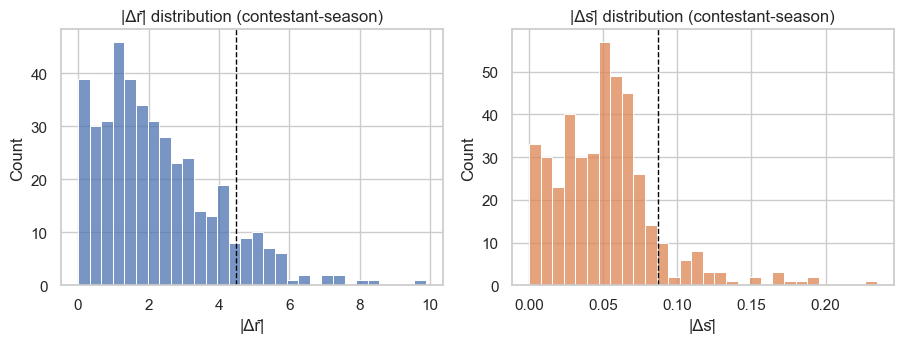

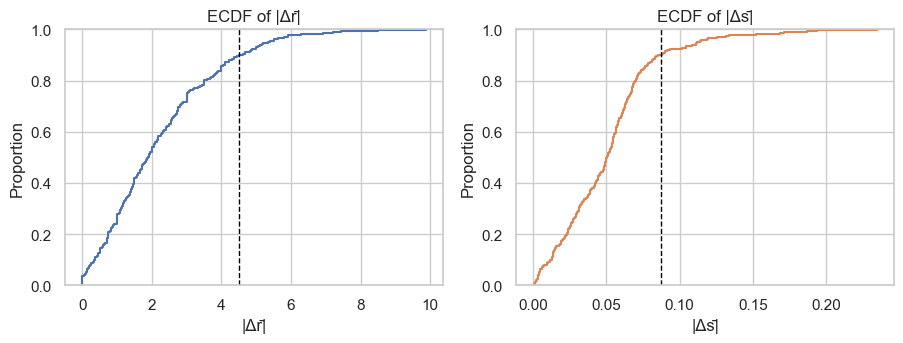

In [125]:
# --- Plot distributions: |Δr̄| and |Δs̄| with quantile threshold ---
abs_dr = disagree_index['delta_r_bar'].abs()
abs_ds = disagree_index['delta_s_bar'].abs()

plt.figure(figsize=(9.2, 3.6))
plt.subplot(1,2,1)
sns.histplot(abs_dr, bins=30, color='#4C72B0')
plt.axvline(thr_r, color='black', linestyle='--', linewidth=1)
plt.title('|Δr̄| distribution (contestant-season)')
plt.xlabel('|Δr̄|')
plt.ylabel('Count')

plt.subplot(1,2,2)
sns.histplot(abs_ds, bins=30, color='#DD8452')
plt.axvline(thr_s, color='black', linestyle='--', linewidth=1)
plt.title('|Δs̄| distribution (contestant-season)')
plt.xlabel('|Δs̄|')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9.2, 3.6))
plt.subplot(1,2,1)
sns.ecdfplot(abs_dr, color='#4C72B0')
plt.axvline(thr_r, color='black', linestyle='--', linewidth=1)
plt.title('ECDF of |Δr̄|')
plt.xlabel('|Δr̄|')

plt.subplot(1,2,2)
sns.ecdfplot(abs_ds, color='#DD8452')
plt.axvline(thr_s, color='black', linestyle='--', linewidth=1)
plt.title('ECDF of |Δs̄|')
plt.xlabel('|Δs̄|')
plt.tight_layout()
plt.show()


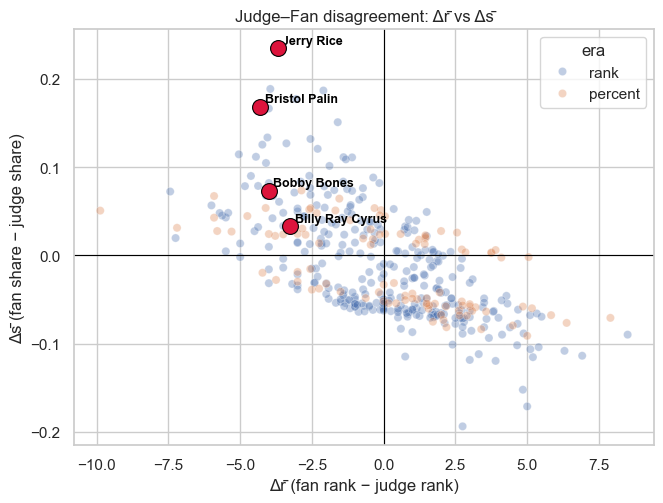

In [126]:
# --- Global evidence plot (G1): Δr̄ vs Δs̄ ---
plt.figure(figsize=(6.8, 5.2))

# 1) background: all contestant–seasons
sns.scatterplot(
    data=disagree_index,
    x='delta_r_bar', y='delta_s_bar',
    hue='era',
    alpha=0.35,          # 弱化背景
    s=35,
    legend=True
)

# axes
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)

plt.title('Judge–Fan disagreement: Δr̄ vs Δs̄')
plt.xlabel('Δr̄ (fan rank − judge rank)')
plt.ylabel('Δs̄ (fan share − judge share)')

# 2) highlight required controversy cases
annotate_cases = [
    (2, 'Jerry Rice'),
    (4, 'Billy Ray Cyrus'),
    (11, 'Bristol Palin'),
    (27, 'Bobby Bones'),
]

highlight = disagree_index.merge(
    pd.DataFrame(annotate_cases, columns=['season','celebrity_name']),
    on=['season','celebrity_name'],
    how='inner'
)

plt.scatter(
    highlight['delta_r_bar'],
    highlight['delta_s_bar'],
    s=130,                   # bigger marker
    c='crimson',              # single strong color
    edgecolors='black',
    linewidths=0.8,
    zorder=5,
    label='Highlighted controversy cases'
)

# 3) annotate names
for _, r in highlight.iterrows():
    plt.text(
        r['delta_r_bar'] + 0.15,
        r['delta_s_bar'] + 0.005,
        r['celebrity_name'],
        fontsize=9,
        weight='bold',
        color='black'
    )

plt.tight_layout()
plt.show()


## Bottom-2 mechanism (judge saves better) with posterior sampling

We simulate posterior fan shares per week, compute Bottom-2 under percent vs rank merge,
apply judge-save, and compare with direct-min elimination.


In [127]:
# --- Bottom-2 mechanism: posterior simulation per week ---

def _safe_judge_vec(g, col, fallback='j_metric'):
    v = g[col].to_numpy(dtype=float)
    if np.isnan(v).any():
        v = g[fallback].to_numpy(dtype=float)
    return v

def _bottom2_probs_from_J(p_samps, w, J):
    B, n = p_samps.shape
    b2_prob = np.zeros(n)
    elim_prob = np.zeros(n)
    elim_direct_prob = np.zeros(n)
    rev = 0.0

    for b in range(B):
        S = J + p_samps[b]
        idxs = np.argsort(S)[:2]
        b2_prob[idxs] += w[b]
        elim_b2 = idxs[np.argmin(J[idxs])]  # judge saves better
        elim_prob[elim_b2] += w[b]
        elim_direct = int(np.argmin(S))
        elim_direct_prob[elim_direct] += w[b]
        if elim_b2 != elim_direct:
            rev += w[b]

    return b2_prob, elim_prob, elim_direct_prob, rev

def bottom2_stats_for_week(panel, pooled_fit, season, week, *, B=800, tau_like=0.15, seed=123):
    out = posterior_draws_for_week(panel, pooled_fit, season, week, B=B, tau_like=tau_like, seed=seed)
    if out is None:
        return None
    g, p_samps, w = out

    # enrich with judge percent & rank shares
    g = g.merge(
        panel[['season','week','celebrity_name','judge_percent','judge_rank_share','j_metric']],
        on=['season','week','celebrity_name'], how='left'
    )

    J_pct = _safe_judge_vec(g, 'judge_percent')
    J_rank = _safe_judge_vec(g, 'judge_rank_share')

    b2_pct, elim_pct, elim_direct_pct, rev_pct = _bottom2_probs_from_J(p_samps, w, J_pct)
    b2_rank, elim_rank, elim_direct_rank, rev_rank = _bottom2_probs_from_J(p_samps, w, J_rank)

    return g, (b2_pct, elim_pct, elim_direct_pct, rev_pct), (b2_rank, elim_rank, elim_direct_rank, rev_rank)

# compute across all eligible weeks
b2_rows = []
rev_rows = []

for s, wk in train_weeks_simple[['season','week']].values.tolist():
    res = bottom2_stats_for_week(panel, pooled_fit, int(s), int(wk), B=800, tau_like=0.15, seed=SEED + int(s)*1000 + int(wk))
    if res is None:
        continue
    g, pct_res, rank_res = res
    b2_pct, elim_pct, elim_direct_pct, rev_pct = pct_res
    b2_rank, elim_rank, elim_direct_rank, rev_rank = rank_res

    names = g['celebrity_name'].to_numpy()
    for i, name in enumerate(names):
        b2_rows.append({
            'season': int(s),
            'week': int(wk),
            'celebrity_name': name,
            'P_bottom2_pct': float(b2_pct[i]),
            'P_elim_pct': float(elim_pct[i]),
            'P_elim_direct_pct': float(elim_direct_pct[i]),
            'P_bottom2_rank': float(b2_rank[i]),
            'P_elim_rank': float(elim_rank[i]),
            'P_elim_direct_rank': float(elim_direct_rank[i]),
        })

    rev_rows.append({
        'season': int(s),
        'week': int(wk),
        'alive_size': int(g.shape[0]),
        'rev_rate_pct': float(rev_pct),
        'rev_rate_rank': float(rev_rank),
    })

bottom2_probs = pd.DataFrame(b2_rows)
rev_df = pd.DataFrame(rev_rows)

bottom2_probs.head(), rev_df.head()


(   season  week     celebrity_name  P_bottom2_pct  P_elim_pct  \
 0       1     2  Evander Holyfield       0.365139    0.365139   
 1       1     2      Joey McIntyre       0.002749    0.001440   
 2       1     2      John O'Hurley       0.460222    0.000000   
 3       1     2       Kelly Monaco       0.005851    0.005292   
 4       1     2      Rachel Hunter       0.316961    0.059831   
 
    P_elim_direct_pct  P_bottom2_rank  P_elim_rank  P_elim_direct_rank  
 0           0.214787        0.550171     0.550171            0.100440  
 1           0.000000        0.062255     0.000284            0.001980  
 2           0.066445        0.000000     0.000000            0.000000  
 3           0.002345        0.056737     0.055195            0.003222  
 4           0.067827        0.353116     0.000000            0.015393  ,
    season  week  alive_size  rev_rate_pct  rev_rate_rank
 0       1     2           6      0.237224       0.511898
 1       1     3           5      0.246138     

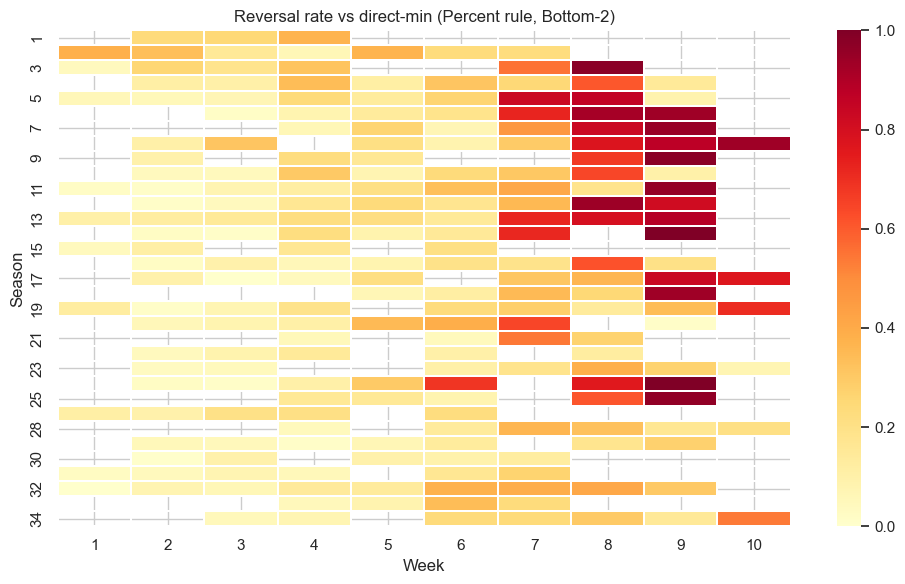

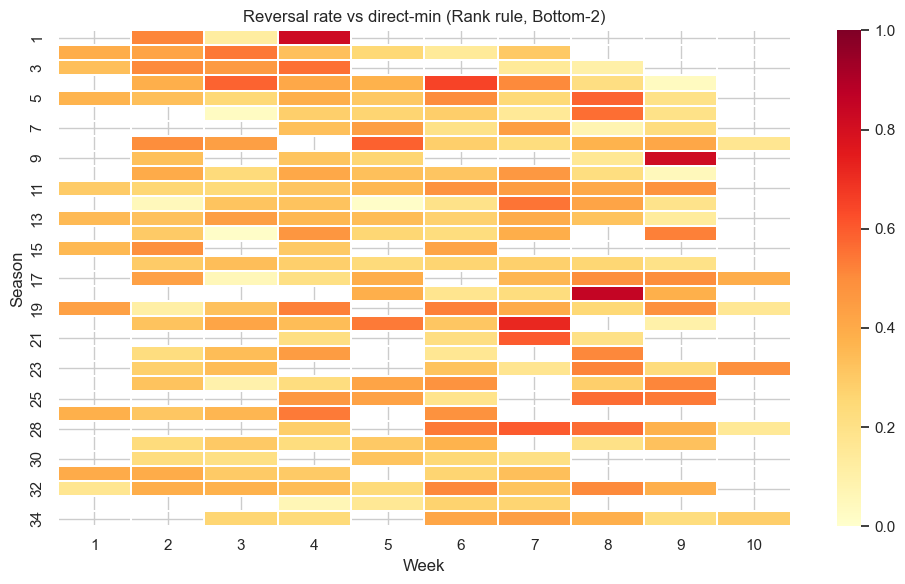

In [128]:
# --- Visualization 1: reversal rate heatmap (by season-week) ---
def _heatmap_rev(df, col, title):
    pivot = df.pivot(index='season', columns='week', values=col)
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.2)
    plt.title(title)
    plt.xlabel('Week')
    plt.ylabel('Season')
    plt.tight_layout()
    plt.show()

_heatmap_rev(rev_df, 'rev_rate_pct', 'Reversal rate vs direct-min (Percent rule, Bottom-2)')
_heatmap_rev(rev_df, 'rev_rate_rank', 'Reversal rate vs direct-min (Rank rule, Bottom-2)')


## Integrated Q3 simulation + controversy case-study (single-pass, shared inputs)

This section implements the four mechanisms using the same (J, p_draw) inputs, computes
week-level reversals, contestant-level impacts, uncertainty intervals, and produces figures.


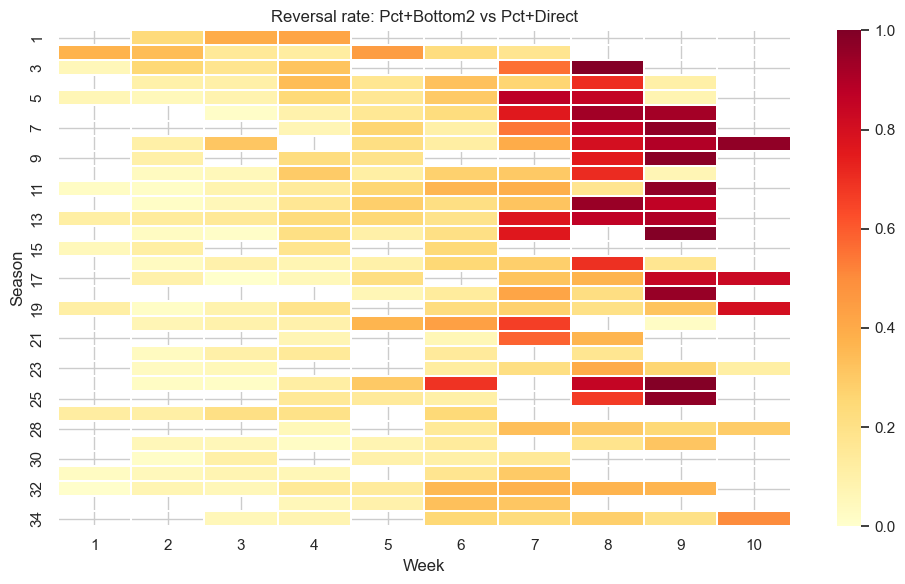

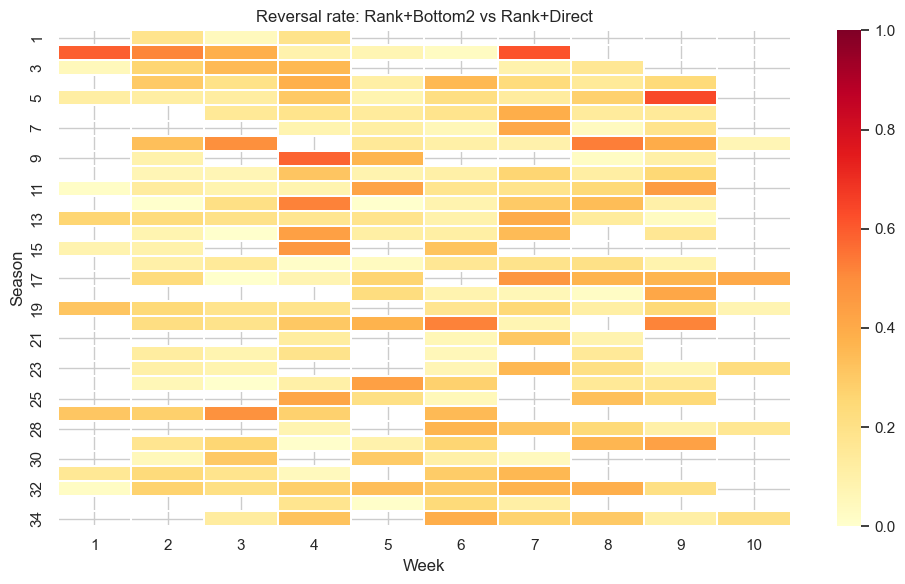

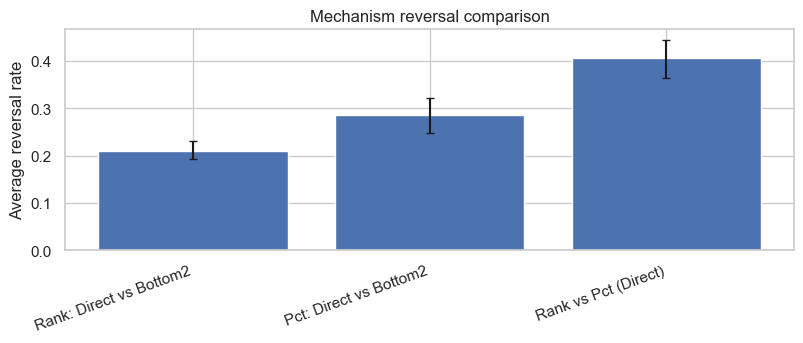

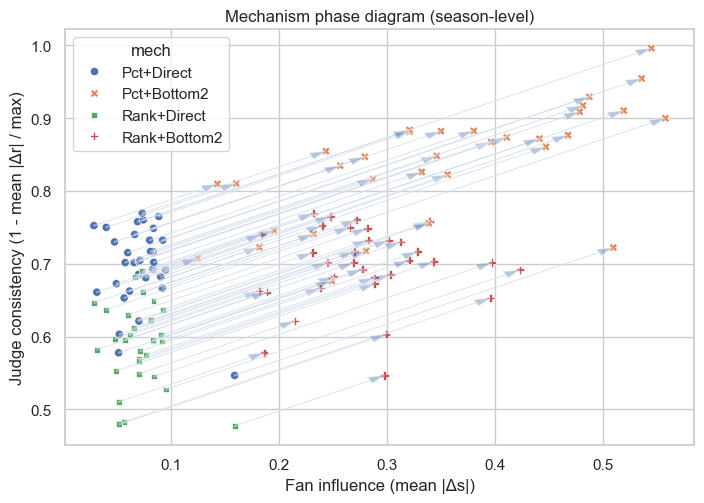

                           Logit Regression Results                           
Dep. Variable:         rev_binary_pct   No. Observations:                  218
Model:                          Logit   Df Residuals:                      213
Method:                           MLE   Df Model:                            4
Date:                Sun, 01 Feb 2026   Pseudo R-squ.:                     inf
Time:                        11:51:53   Log-Likelihood:            -7.8001e-10
converged:                      False   LL-Null:                        0.0000
Covariance Type:            nonrobust   LLR p-value:                     1.000
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      26.3562   3.58e+04      0.001      0.999   -7.02e+04    7.02e+04
alive_size               2.556e-15   6.93e+04   3.69e-20      1.000   -1.36e+05    1.36e+05


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:227: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/opt/anaconda3/lib/p

In [129]:
# --- Ensure post_draws available ---
if 'post_draws' not in globals():
    post_draws = {}
    if 'posterior_draws_for_week' in globals() and 'panel' in globals() and 'pooled_fit' in globals() and 'train_weeks' in globals():
        for s, wk in train_weeks[['season','week']].values.tolist():
            out = posterior_draws_for_week(panel, pooled_fit, int(s), int(wk), B=600, tau_like=0.15, seed=SEED + int(s)*1000 + int(wk))
            if out is None:
                continue
            g, p_samps, w = out
            post_draws[(int(s), int(wk))] = {'p_draws': p_samps, 'names': g['celebrity_name'].tolist()}

# --- Integrated simulation pipeline (fixed seed, no refit) ---
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# ---------- helpers: eligibility & inputs ----------
def _infer_flags(df):
    d = df.copy()
    if 'alive' not in d.columns:
        d['alive'] = True
    # finale flag
    if 'is_finale' in d.columns:
        d['is_finale'] = d['is_finale'].astype(bool)
    elif 'is_final_week' in d.columns:
        d['is_finale'] = d['is_final_week'].astype(bool)
    elif 'is_final_week_end' in d.columns:
        d['is_finale'] = d['is_final_week_end'].astype(bool)
    else:
        d['is_finale'] = False
    # single elimination
    if 'is_single_elim_week' in d.columns:
        d['is_single_elim_week'] = d['is_single_elim_week'].astype(bool)
    elif 'elim_this_week_end' in d.columns:
        g = d.groupby(['season','week'])['elim_this_week_end'].sum().reset_index(name='elim_cnt')
        d = d.merge(g, on=['season','week'], how='left')
        d['is_single_elim_week'] = (d['elim_cnt'] == 1)
    else:
        d['is_single_elim_week'] = True
    return d

def _select_J_share(df_week, *, temp=1.0):
    # prefer existing share
    for col in ['J_share','judge_share','judge_percent','judge_pct']:
        if col in df_week.columns and df_week[col].notna().any():
            return df_week[col].astype(float).to_numpy(), col
    # fallback to judge scores
    for col in ['total_judge_score','judge_total','j_metric']:
        if col in df_week.columns and df_week[col].notna().any():
            J = df_week[col].astype(float).to_numpy()
            if np.any(J < 0) or J.sum() <= 0:
                z = J / max(temp, 1e-6)
                z = z - np.max(z)
                e = np.exp(z)
                return e / e.sum(), col
            return J / J.sum(), col
    raise KeyError('No judge signal column found for J_share.')

def _get_post_draws_for_week(post_draws, season, week, names):
    # long dataframe case
    if isinstance(post_draws, pd.DataFrame):
        required = {'season','week','celebrity_name','b','p_draw'}
        if not required.issubset(post_draws.columns):
            raise KeyError('post_draws long df must have season, week, celebrity_name, b, p_draw')
        g = post_draws[(post_draws['season']==season) & (post_draws['week']==week)]
        if g.empty:
            return None, None
        order = pd.Index(names)
        g = g.copy()
        g['celebrity_name'] = pd.Categorical(g['celebrity_name'], categories=order, ordered=True)
        g = g.sort_values(['b','celebrity_name'])
        p = g.pivot_table(index='b', columns='celebrity_name', values='p_draw')
        p = p.reindex(columns=order)
        return p.to_numpy(), list(p.columns)

    # dict-like cases
    key = (season, week)
    if isinstance(post_draws, dict) and key in post_draws:
        val = post_draws[key]
        if isinstance(val, dict) and 'p_draws' in val and 'names' in val:
            return val['p_draws'], list(val['names'])
        if isinstance(val, (list, tuple)) and len(val) == 2:
            return val[0], list(val[1])
        if isinstance(val, np.ndarray):
            return val, names
    return None, None

def _rank_desc(x):
    return pd.Series(x).rank(ascending=False, method='average').to_numpy()

def _order_by(score, J, p, names, *, worst='min'):
    names = np.asarray(names)
    name_key = np.argsort(names)
    if worst == 'min':
        score_key = score
    else:
        score_key = -score
    # tie-break: score, then J (worse = smaller), then p (worse = smaller), then name
    idx = np.lexsort((name_key, p, J, score_key))
    return idx

def simulate_week(p_draw_b, J_share, names, mechanism, *, wJ=0.5, wF=0.5):
    p = np.asarray(p_draw_b)
    J = np.asarray(J_share)
    names = np.asarray(names)
    if mechanism.startswith('rank'):
        rJ = _rank_desc(J)
        rF = _rank_desc(p)
        S = rJ + rF
        order = _order_by(S, J, p, names, worst='max')
    else:
        S = wJ * J + wF * p
        order = _order_by(S, J, p, names, worst='min')

    bottom2 = list(names[order[:2]])

    if mechanism.endswith('direct'):
        elim = names[order[0]]
    else:
        # eliminate worse J among bottom2 (smaller J is worse)
        b2_idx = order[:2]
        jvals = J[b2_idx]
        pvals = p[b2_idx]
        name_key = np.argsort(names[b2_idx])
        elim_idx = b2_idx[np.lexsort((name_key, pvals, jvals))[0]]
        elim = names[elim_idx]

    return elim, bottom2

# ---------- Step 0: eligibility + alive sets ----------
df_weekly2 = _infer_flags(df_weekly)
eligible = df_weekly2[(df_weekly2['alive']==True) & (~df_weekly2['is_finale']) & (df_weekly2['is_single_elim_week'])]
alive_size = eligible.groupby(['season','week'])['celebrity_name'].nunique().reset_index(name='alive_n')
eligible = eligible.merge(alive_size, on=['season','week'], how='left')
eligible = eligible[eligible['alive_n'] >= 3]

alive_sets = (eligible.groupby(['season','week'])['celebrity_name']
              .apply(list).to_dict())
eligible_weeks = sorted(alive_sets.keys())

# ---------- Step 1: weekly disagreement metrics ----------
disagree_rows = []
p_draws_cache = {}

for (s, w) in eligible_weeks:
    names = alive_sets[(s, w)]
    dfw = eligible[(eligible['season']==s) & (eligible['week']==w) & (eligible['celebrity_name'].isin(names))].copy()

    p_draws, aligned_names = _get_post_draws_for_week(post_draws, s, w, names)
    if p_draws is None:
        continue
    if list(aligned_names) != list(names):
        aligned_set = set(aligned_names)
        names = [n for n in names if n in aligned_set]
        if len(names) < 3:
            continue
        dfw = dfw[dfw['celebrity_name'].isin(names)].copy()
        idx_map = {n:i for i,n in enumerate(aligned_names)}
        cols = [idx_map[n] for n in names]
        p_draws = p_draws[:, cols]
    p_draws_cache[(s,w)] = (names, p_draws)

    p_hat = p_draws.mean(axis=0)
    J_share, J_col = _select_J_share(dfw)

    r_fan = _rank_desc(p_hat)
    r_judge = _rank_desc(J_share)

    for i, name in enumerate(names):
        disagree_rows.append({
            'season': s, 'week': w, 'celebrity_name': name,
            'p_hat': float(p_hat[i]), 'J_share': float(J_share[i]),
            'r_fan': float(r_fan[i]), 'r_judge': float(r_judge[i]),
            'delta_r': float(r_fan[i] - r_judge[i]),
            'delta_s': float(p_hat[i] - J_share[i]),
            'alive_n': int(len(names)),
        })

df_disagree_weekly = pd.DataFrame(disagree_rows)

# ---------- Step 2 & 3: simulate weekly mechanisms ----------
mechs = ['rank_direct','rank_bottom2','pct_direct','pct_bottom2']
rev_rows = []
mech_week_elims = []

for (s, w), (names, p_draws) in p_draws_cache.items():
    dfw = eligible[(eligible['season']==s) & (eligible['week']==w) & (eligible['celebrity_name'].isin(names))].copy()
    J_share, _ = _select_J_share(dfw)
    B = p_draws.shape[0]

    elim = {m: [] for m in mechs}
    bottom2 = {m: [] for m in mechs}

    for b in range(B):
        p_b = p_draws[b]
        for m in mechs:
            e, b2 = simulate_week(p_b, J_share, names, m)
            elim[m].append(e)
            bottom2[m].append(tuple(sorted(b2)))

    elim = {m: np.array(v) for m,v in elim.items()}
    bottom2 = {m: np.array(v, dtype=object) for m,v in bottom2.items()}

    rev_rate_rank = np.mean(elim['rank_bottom2'] != elim['rank_direct'])
    rev_rate_pct = np.mean(elim['pct_bottom2'] != elim['pct_direct'])
    rev_rate_rank_vs_pct = np.mean(elim['rank_direct'] != elim['pct_direct'])

    b2_diff_rank = np.mean(bottom2['rank_bottom2'] != bottom2['rank_direct'])
    b2_diff_pct = np.mean(bottom2['pct_bottom2'] != bottom2['pct_direct'])

    save_flip_rank = np.mean(((bottom2['rank_bottom2'] == bottom2['rank_direct']).all(axis=1)) & (elim['rank_bottom2'] != elim['rank_direct']))
    save_flip_pct = np.mean(((bottom2['pct_bottom2'] == bottom2['pct_direct']).all(axis=1)) & (elim['pct_bottom2'] != elim['pct_direct']))
    rev_rows.append({
        'season': s, 'week': w, 'alive_n': len(names),
        'rev_rate_rank': float(rev_rate_rank),
        'rev_rate_pct': float(rev_rate_pct),
        'rev_rate_rank_vs_pct': float(rev_rate_rank_vs_pct),
        'bottom2_diff_rank': float(b2_diff_rank),
        'bottom2_diff_pct': float(b2_diff_pct),
        'B': int(B),
    })

    for m in mechs:
        mech_week_elims.append({
            'season': s, 'week': w, 'mechanism': m,
            'elim_names': elim[m],
            'bottom2_sets': bottom2[m],
        })

rev_df = pd.DataFrame(rev_rows)

# ---------- Step 4: contestant-level season impacts ----------
def simulate_season_paths(season, mechanism):
    weeks = sorted([wk for (s,wk) in eligible_weeks if s == season])
    weeks = [wk for wk in weeks if (season, wk) in p_draws_cache]
    if not weeks:
        return None
    alive0 = list(alive_sets[(season, weeks[0])])
    _, p0 = p_draws_cache[(season, weeks[0])]
    B = p0.shape[0]
    t_elim = {name: np.full(B, np.inf) for name in alive0}

    for b in range(B):
        alive = set(alive0)
        for wk in weeks:
            names_w, p_draws = p_draws_cache[(season, wk)]
            names = [n for n in names_w if n in alive]
            if len(names) < 2:
                break
            idx = [names_w.index(n) for n in names]
            p_b = p_draws[b, idx]
            dfw = eligible[(eligible['season']==season) & (eligible['week']==wk) & (eligible['celebrity_name'].isin(names))].copy()
            J_share, _ = _select_J_share(dfw)
            j_map = {n:j for n,j in zip(dfw['celebrity_name'].tolist(), J_share)}
            J = np.array([j_map[n] for n in names])

            elim, _ = simulate_week(p_b, J, names, mechanism)
            if np.isinf(t_elim.get(elim, np.inf)[b]):
                t_elim[elim][b] = wk
            alive.discard(elim)
    return t_elim

contestant_impact_rows = []
seasons = sorted({s for (s,_) in eligible_weeks})
for s in seasons:
    t_by_mech = {m: simulate_season_paths(s, m) for m in mechs}
    if any(v is None for v in t_by_mech.values()):
        continue
    names = list(t_by_mech['pct_direct'].keys())

    for name in names:
        stats = {}
        for m in mechs:
            t = t_by_mech[m][name]
            stats[m] = {
                'E_T': float(np.mean(t[np.isfinite(t)]) if np.any(np.isfinite(t)) else np.nan),
                'P_finals': float(np.mean(~np.isfinite(t))),
            }
        dE = stats['pct_bottom2']['E_T'] - stats['pct_direct']['E_T']
        dP = stats['pct_bottom2']['P_finals'] - stats['pct_direct']['P_finals']
        contestant_impact_rows.append({
            'season': s, 'celebrity_name': name,
            'E_T_pct_direct': stats['pct_direct']['E_T'],
            'E_T_pct_bottom2': stats['pct_bottom2']['E_T'],
            'P_finals_pct_direct': stats['pct_direct']['P_finals'],
            'P_finals_pct_bottom2': stats['pct_bottom2']['P_finals'],
            'dE_T_pct_bottom2_minus_direct': dE,
            'dP_finals_pct_bottom2_minus_direct': dP,
        })

contestant_impact = pd.DataFrame(contestant_impact_rows)

# ---------- Step 5: case-study weekly probabilities ----------
try:
    from scipy.stats import beta as beta_dist
    def beta_ci(k, B, alpha=0.05):
        return beta_dist.ppf(alpha/2, 1+k, 1+B-k), beta_dist.ppf(1-alpha/2, 1+k, 1+B-k)
except Exception:
    def beta_ci(k, B, alpha=0.05):
        p = (k+1)/(B+2)
        se = np.sqrt(p*(1-p)/max(B,1))
        z = 1.96
        return max(0, p - z*se), min(1, p + z*se)

def case_weekly_probs(season, name, mechanisms=('pct_direct','pct_bottom2')):
    rows = []
    weeks = sorted([wk for (s,wk) in eligible_weeks if s == season])
    weeks = [wk for wk in weeks if (season, wk) in p_draws_cache]
    if not weeks:
        return pd.DataFrame()
    _, p0 = p_draws_cache[(season, weeks[0])]
    B = p0.shape[0]

    for wk in weeks:
        names_w, p_draws = p_draws_cache[(season, wk)]
        if name not in names_w:
            continue
        dfw = eligible[(eligible['season']==season) & (eligible['week']==wk) & (eligible['celebrity_name'].isin(names_w))].copy()
        J_share, _ = _select_J_share(dfw)
        J_map = {n:j for n,j in zip(dfw['celebrity_name'].tolist(), J_share)}
        J = np.array([J_map[n] for n in names_w])

        for m in mechanisms:
            elim_hits = 0
            b2_hits = 0
            for b in range(B):
                p_b = p_draws[b]
                elim, b2 = simulate_week(p_b, J, names_w, m)
                if elim == name:
                    elim_hits += 1
                if name in b2:
                    b2_hits += 1
            lo_e, hi_e = beta_ci(elim_hits, B)
            lo_b, hi_b = beta_ci(b2_hits, B)
            rows.append({
                'season': season, 'week': wk, 'celebrity_name': name,
                'mechanism': m,
                'elim_prob': elim_hits / B, 'elim_lo': lo_e, 'elim_hi': hi_e,
                'bottom2_prob': b2_hits / B, 'b2_lo': lo_b, 'b2_hi': hi_b,
            })
    return pd.DataFrame(rows)

# ---------- Step 6: visuals + exports ----------
sns.set_theme(style='whitegrid', font_scale=1.0)

def plot_rev_heatmap(df, col, title, out_path):
    piv = df.pivot(index='season', columns='week', values=col)
    plt.figure(figsize=(10, 6))
    sns.heatmap(piv, cmap='YlOrRd', vmin=0, vmax=1, linewidths=0.2)
    plt.title(title)
    plt.xlabel('Week')
    plt.ylabel('Season')
    plt.tight_layout()
    plt.savefig(out_path, dpi=300)
    plt.show()

plot_rev_heatmap(rev_df, 'rev_rate_pct', 'Reversal rate: Pct+Bottom2 vs Pct+Direct', 'fig_rev_heatmap_pct.png')
plot_rev_heatmap(rev_df, 'rev_rate_rank', 'Reversal rate: Rank+Bottom2 vs Rank+Direct', 'fig_rev_heatmap_rank.png')

def bootstrap_mean_ci(x, n_boot=1000):
    rng = np.random.default_rng(SEED)
    x = np.asarray(x)
    if len(x) == 0:
        return np.nan, (np.nan, np.nan)
    boots = []
    for _ in range(n_boot):
        samp = rng.choice(x, size=len(x), replace=True)
        boots.append(np.mean(samp))
    lo, hi = np.quantile(boots, [0.025, 0.975])
    return np.mean(x), (lo, hi)

pairs = {
    'Rank: Direct vs Bottom2': rev_df['rev_rate_rank'],
    'Pct: Direct vs Bottom2': rev_df['rev_rate_pct'],
    'Rank vs Pct (Direct)': rev_df['rev_rate_rank_vs_pct'],
}
bar_rows = []
for k,v in pairs.items():
    m,(lo,hi) = bootstrap_mean_ci(v)
    bar_rows.append({'pair': k, 'mean': m, 'lo': lo, 'hi': hi})
bar_df = pd.DataFrame(bar_rows)

plt.figure(figsize=(8.2, 3.6))
plt.bar(bar_df['pair'], bar_df['mean'], yerr=[bar_df['mean']-bar_df['lo'], bar_df['hi']-bar_df['mean']], capsize=3)
plt.ylabel('Average reversal rate')
plt.title('Mechanism reversal comparison')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('fig_rev_bar.png', dpi=300)
plt.show()

season_features = (df_disagree_weekly.groupby('season')
                   .agg(fan_influence=('delta_s', lambda x: np.mean(np.abs(x))),
                        judge_consistency=('delta_r', lambda x: 1 - np.mean(np.abs(x)) / (np.max(np.abs(x))+1e-9)))
                   .reset_index())
season_rev = rev_df.groupby('season')[['rev_rate_pct','rev_rate_rank']].mean().reset_index()
season_phase = season_features.merge(season_rev, on='season', how='left')

points = []
for _, r in season_phase.iterrows():
    x = r['fan_influence']
    y = r['judge_consistency']
    points.extend([
        {'season': r['season'], 'mech': 'Pct+Direct', 'x': x, 'y': y},
        {'season': r['season'], 'mech': 'Pct+Bottom2', 'x': x + r['rev_rate_pct'], 'y': y + 0.5*r['rev_rate_pct']},
        {'season': r['season'], 'mech': 'Rank+Direct', 'x': x, 'y': y - 0.5*r['rev_rate_rank']},
        {'season': r['season'], 'mech': 'Rank+Bottom2', 'x': x + r['rev_rate_rank'], 'y': y},
    ])
phase_df = pd.DataFrame(points)

plt.figure(figsize=(7.2, 5.2))
sns.scatterplot(data=phase_df, x='x', y='y', hue='mech', style='mech')
for s, g in phase_df.groupby('season'):
    g = g.set_index('mech')
    if 'Pct+Direct' in g.index and 'Pct+Bottom2' in g.index:
        a = g.loc['Pct+Direct']; b = g.loc['Pct+Bottom2']
        plt.arrow(a['x'], a['y'], b['x']-a['x'], b['y']-a['y'], length_includes_head=True, head_width=0.01, alpha=0.4)
    if 'Rank+Direct' in g.index and 'Rank+Bottom2' in g.index:
        a = g.loc['Rank+Direct']; b = g.loc['Rank+Bottom2']
        plt.arrow(a['x'], a['y'], b['x']-a['x'], b['y']-a['y'], length_includes_head=True, head_width=0.01, alpha=0.4)

plt.xlabel('Fan influence (mean |Δs|)')
plt.ylabel('Judge consistency (1 - mean |Δr| / max)')
plt.title('Mechanism phase diagram (season-level)')
plt.tight_layout()
plt.savefig('fig_phase_diagram.png', dpi=300)
plt.show()

if 'df_tag' in globals() and 'contestant_impact' in globals():
    df_tag2 = df_tag.merge(contestant_impact[['season','celebrity_name','dE_T_pct_bottom2_minus_direct']],
                           on=['season','celebrity_name'], how='left')
    plt.figure(figsize=(7.2,5.6))
    sns.scatterplot(data=df_tag2, x='m_r', y='m_s', hue='label',
                    size='dE_T_pct_bottom2_minus_direct', sizes=(30, 250))
    plt.axvline(0, color='black', linewidth=0.8); plt.axhline(0, color='black', linewidth=0.8)
    plt.xlabel(r'Median $\Delta r$'); plt.ylabel(r'Median $\Delta s$')
    plt.title('Archetypes with mechanism impact (ΔE[T])')
    plt.tight_layout()
    plt.savefig('fig_archetype_impact.png', dpi=300)
    plt.show()

CASES = []  # e.g., [(27, 'Bobby Bones'), (11, 'Bristol Palin')]
for season, name in CASES:
    df_case_probs = case_weekly_probs(season, name, mechanisms=('pct_direct','pct_bottom2'))
    if df_case_probs.empty:
        continue
    df_delta = df_disagree_weekly[(df_disagree_weekly['season']==season) & (df_disagree_weekly['celebrity_name']==name)]
    fig, axes = plt.subplots(3, 1, figsize=(9.2, 9.6))
    axes[0].bar(df_delta['week'], df_delta['delta_s'], color=['#4C72B0' if v>=0 else '#C44E52' for v in df_delta['delta_s']])
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'{name} (Season {season}) — weekly Δs')

    axes[1].plot([0,1],[1,1], alpha=0)
    axes[1].text(0.02,0.8,'Survival curves: compute from t_elim draws if needed', transform=axes[1].transAxes)
    axes[1].set_axis_off()

    for m in ['pct_direct','pct_bottom2']:
        g = df_case_probs[df_case_probs['mechanism']==m]
        axes[2].errorbar(g['week'], g['elim_prob'], yerr=[g['elim_prob']-g['elim_lo'], g['elim_hi']-g['elim_prob']],
                         label=m, marker='o')
    axes[2].set_title('Weekly elimination probability (with 95% CI)')
    axes[2].set_xlabel('Week'); axes[2].set_ylabel('P(elim)')
    axes[2].legend()

    plt.tight_layout()
    out_name = f"fig_case_{season}_{name.replace(' ', '_')}.png"
    plt.savefig(out_name, dpi=300)
    plt.show()

# ---------- Step 7: reversal model ----------
feat_rows = []
for (s,w), (names, p_draws) in p_draws_cache.items():
    dfw = eligible[(eligible['season']==s) & (eligible['week']==w) & (eligible['celebrity_name'].isin(names))].copy()
    J_share, _ = _select_J_share(dfw)
    p_hat = p_draws.mean(axis=0)

    order = _order_by(J_share + p_hat, J_share, p_hat, names, worst='min')
    b2_idx = order[:2]
    a, b = b2_idx

    feat_rows.append({
        'season': s, 'week': w,
        'alive_size': len(names),
        'abs_J_bottom2_diff': float(abs(J_share[a] - J_share[b])),
        'abs_p_bottom2_diff': float(abs(p_hat[a] - p_hat[b])),
        'max_abs_delta_s_bottom2': float(max(abs(p_hat[a]-J_share[a]), abs(p_hat[b]-J_share[b]))),
    })

feat_df = pd.DataFrame(feat_rows).merge(rev_df, on=['season','week'], how='left')
feat_df['rev_binary_pct'] = (feat_df['rev_rate_pct'] > 0).astype(int)

try:
    import statsmodels.api as sm
    X = feat_df[['alive_size','abs_J_bottom2_diff','abs_p_bottom2_diff','max_abs_delta_s_bottom2']].copy()
    X = (X - X.mean()) / (X.std(ddof=0)+1e-9)
    X = sm.add_constant(X)
    y = feat_df['rev_binary_pct']
    logit = sm.Logit(y, X).fit(disp=False)
    print(logit.summary())
except Exception as e:
    print('Logit model skipped:', e)

try:
    from sklearn.tree import DecisionTreeClassifier
    from sklearn.model_selection import cross_val_score
    X = feat_df[['alive_size','abs_J_bottom2_diff','abs_p_bottom2_diff','max_abs_delta_s_bottom2']].to_numpy()
    y = feat_df['rev_binary_pct'].to_numpy()
    clf = DecisionTreeClassifier(max_depth=3, random_state=SEED)
    acc = cross_val_score(clf, X, y, cv=5).mean()
    clf.fit(X, y)
    print('Tree CV acc:', acc)
except Exception as e:
    print('Tree model skipped:', e)

# ---------- Exports ----------
rev_df.to_csv('rev_df.csv', index=False)
contestant_impact.to_csv('contestant_impact.csv', index=False)

# ---------- Case summary sentences ----------
for season, name in CASES:
    df_case_probs = case_weekly_probs(season, name, mechanisms=('pct_direct','pct_bottom2'))
    if df_case_probs.empty:
        continue
    week_rev = rev_df[rev_df['season']==season]['rev_rate_pct'].mean()
    row = contestant_impact[(contestant_impact['season']==season) & (contestant_impact['celebrity_name']==name)]
    if not row.empty:
        dE = row['dE_T_pct_bottom2_minus_direct'].iloc[0]
        dP = row['dP_finals_pct_bottom2_minus_direct'].iloc[0]
        print(f"For contestant {name} (Season {season}), switching from Pct+Direct to Pct+Bottom2 changes the eliminated contestant in {100*week_rev:.1f}% of posterior draws; {name}'s expected elimination week shifts by {dE:.2f} weeks and finals probability changes by {dP:.3f}.")



### post_draws builder (fallback if missing)


In [130]:
# --- Build post_draws if missing (uses existing posterior_draws_for_week if available) ---
if 'post_draws' not in globals():
    post_draws = {}
    if 'posterior_draws_for_week' in globals() and 'panel' in globals() and 'pooled_fit' in globals() and 'train_weeks' in globals():
        for s, wk in train_weeks[['season','week']].values.tolist():
            out = posterior_draws_for_week(panel, pooled_fit, int(s), int(wk), B=600, tau_like=0.15, seed=SEED + int(s)*1000 + int(wk))
            if out is None:
                continue
            g, p_samps, w = out
            # use unweighted draws; weights w used later only for likelihood reweighting if desired
            post_draws[(int(s), int(wk))] = {'p_draws': p_samps, 'names': g['celebrity_name'].tolist()}
        print(f'post_draws built for {len(post_draws)} weeks from posterior_draws_for_week')
    else:
        raise NameError('post_draws is not defined. Provide post_draws or define posterior_draws_for_week + panel + pooled_fit + train_weeks.')



## Rank vs Percentage (no Bottom-2): candidate selection + per-contestant analysis

We identify additional controversy candidates using the Judge–Fan Disagreement Index and require weeks with high rank-vs-pct flip rate (>20%). Then we quantify how Rank vs Percentage changes outcomes (weekly flip, elimination risk, survival curves).


Selected cases (required + 2 extras):
 season   celebrity_name                                          reason
      2       Jerry Rice absΔr̄=3.69, absΔs̄=0.234, max weekly flip=0.87
      4  Billy Ray Cyrus absΔr̄=3.25, absΔs̄=0.033, max weekly flip=0.75
     11    Bristol Palin  absΔr̄=4.3, absΔs̄=0.168, max weekly flip=0.97
     27      Bobby Bones  absΔr̄=4.0, absΔs̄=0.073, max weekly flip=0.57
     27          Tinashe   absΔr̄=8.5, absΔs̄=0.09, max weekly flip=0.57
     31 Vinny Guadagnino absΔr̄=9.88, absΔs̄=0.051, max weekly flip=0.33


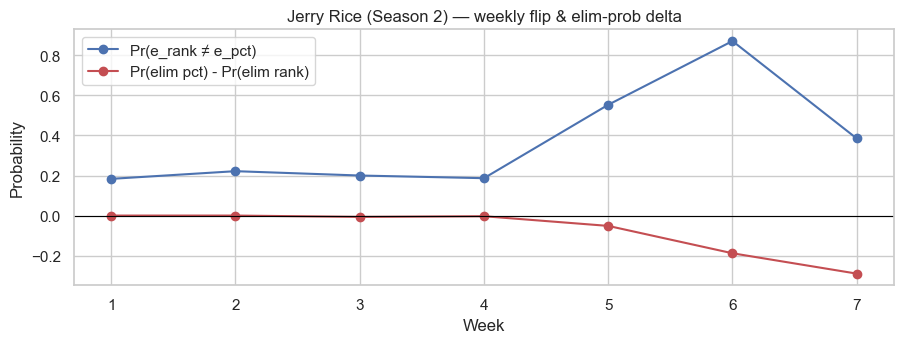

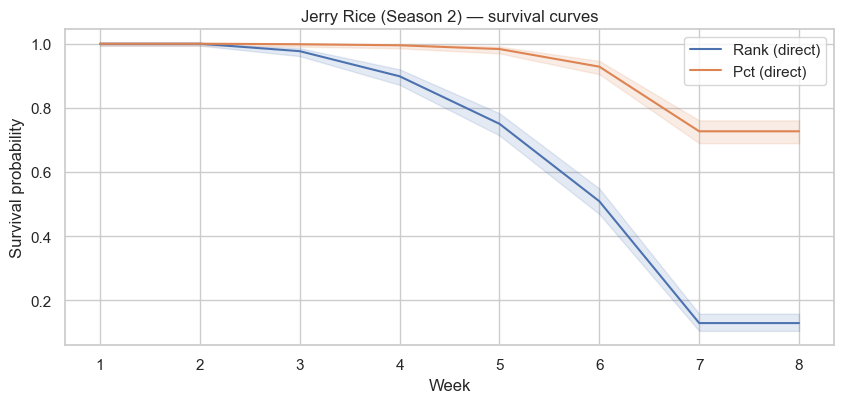

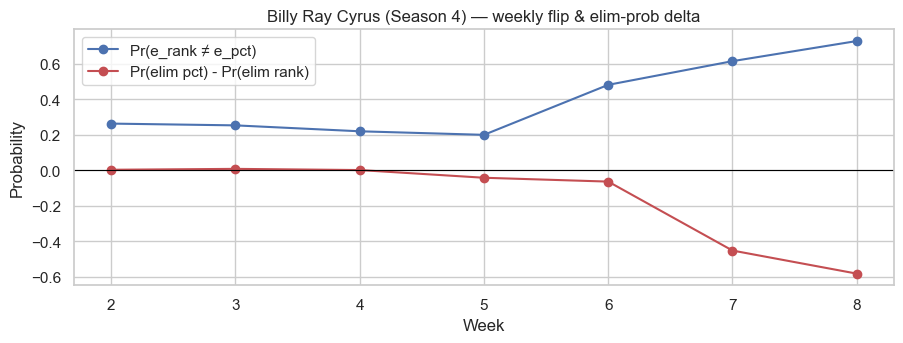

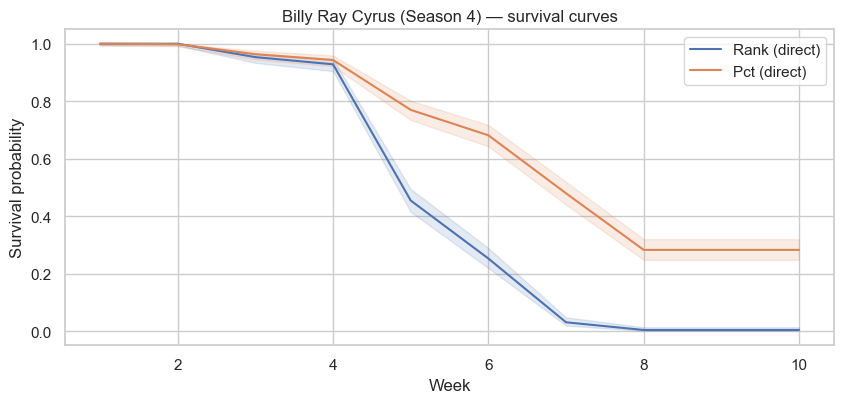

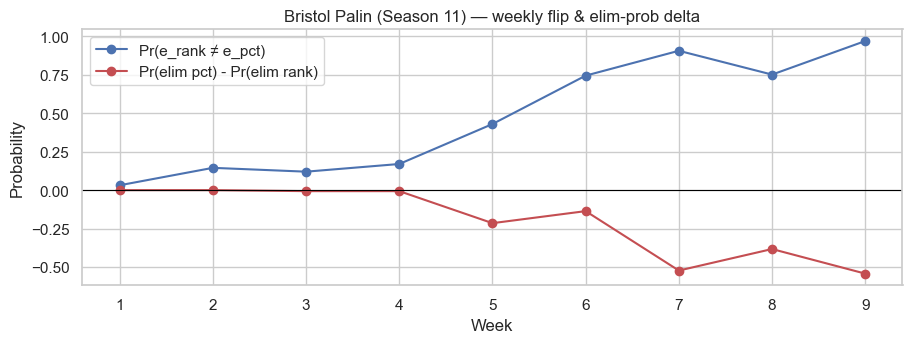

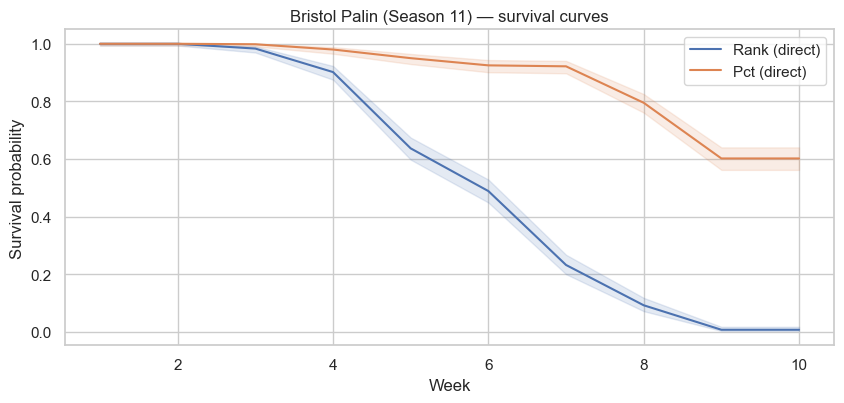

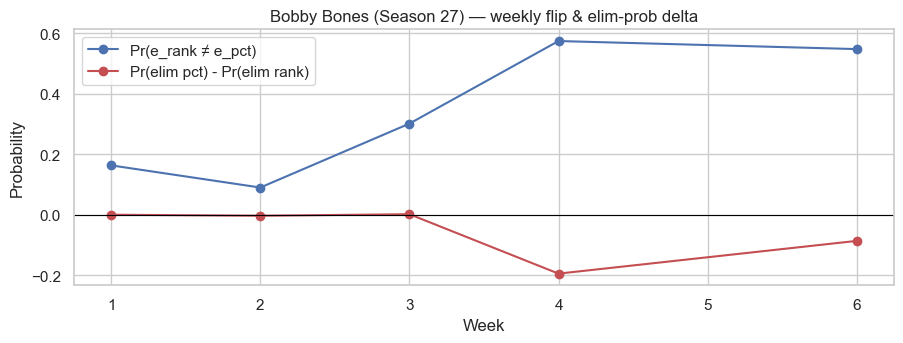

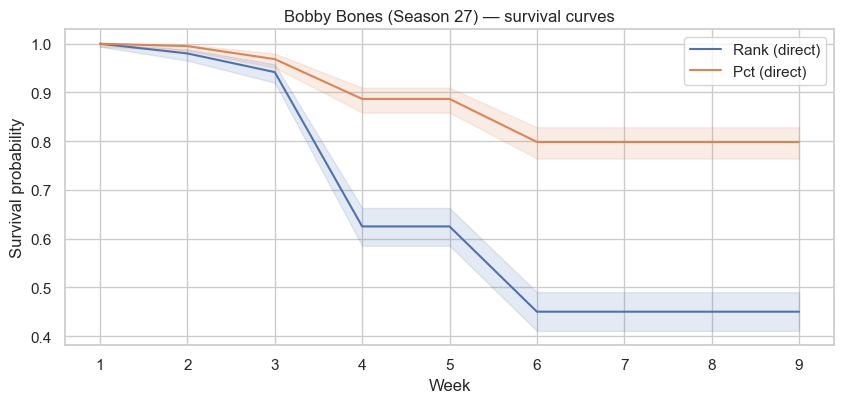

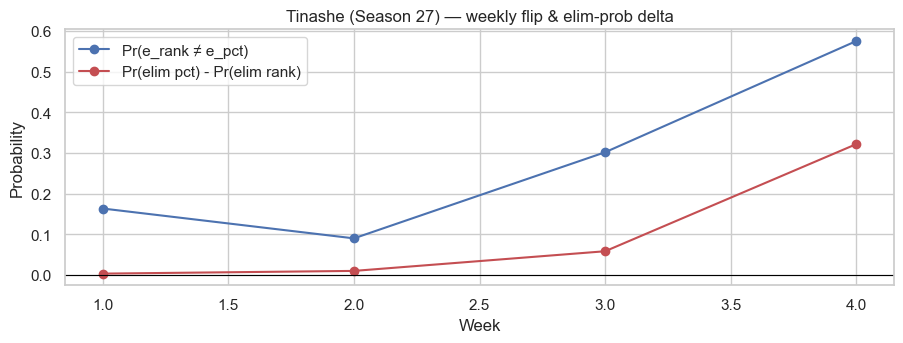

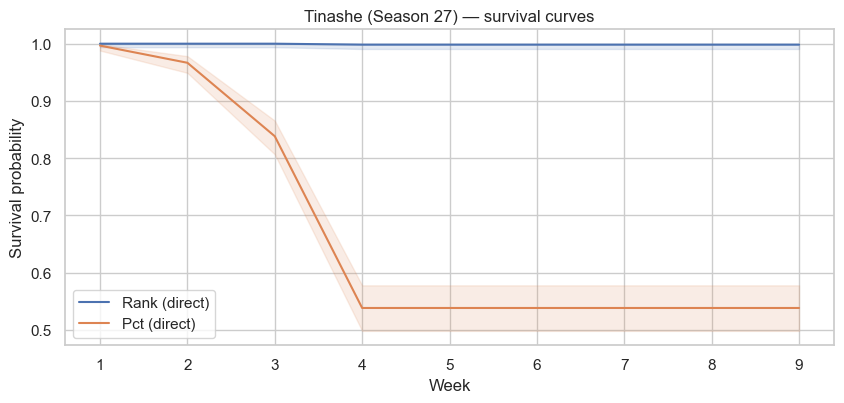

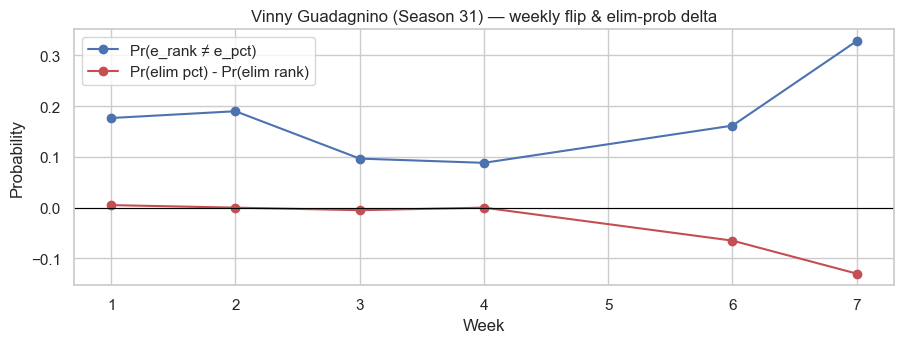

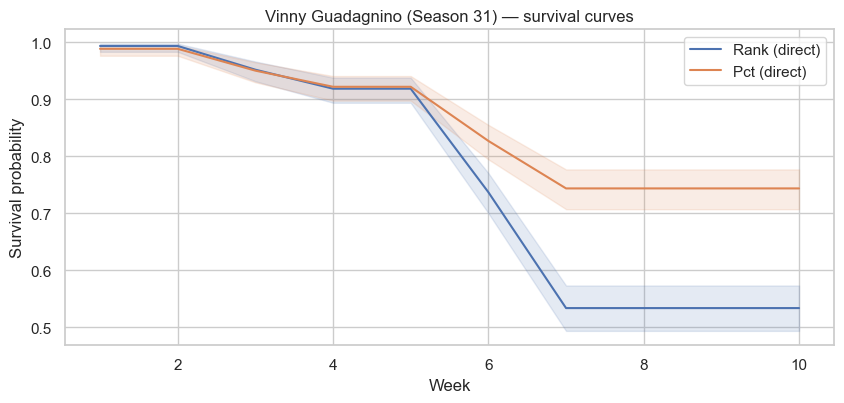

Rank vs Pct (direct) summary for selected cases:
 season   celebrity_name  dE_T_elim  dE_5pct  dE_95pct  dP_finals  survival_area_diff  max_week_flip
      2       Jerry Rice   1.968333      0.0       5.0   0.598333            1.968333       0.871667
      4  Billy Ray Cyrus   2.050000      0.0       6.0   0.278333            2.053333       0.726667
     11    Bristol Palin   3.426667      0.0       7.0   0.595000            3.426667       0.970000
     27      Bobby Bones   1.958333      0.0       6.0   0.348333            1.958333       0.575000
     27          Tinashe  -2.958333     -7.0       0.0  -0.460000            2.958333       0.575000
     31 Vinny Guadagnino   0.925000     -4.0       5.0   0.210000            0.948333       0.328333


In [131]:

# --- Candidate selection (add 2 extra cases) ---
required_cases = [
    (2, 'Jerry Rice'),
    (4, 'Billy Ray Cyrus'),
    (11, 'Bristol Palin'),
    (27, 'Bobby Bones'),
]

# contestant-week flip exposure (rank vs pct, direct)
flip_week = rev_df[['season','week','rev_rate_rank_vs_pct']].copy()
contestant_week = eligible[['season','week','celebrity_name']].drop_duplicates()
contestant_week = contestant_week.merge(flip_week, on=['season','week'], how='left')

flip_by_contestant = (contestant_week.groupby(['season','celebrity_name'])
                      .agg(max_flip=('rev_rate_rank_vs_pct','max'),
                           mean_flip=('rev_rate_rank_vs_pct','mean'),
                           n_weeks=('week','nunique'))
                      .reset_index())

# disagreement index + flip constraint
cand = disagree_index.copy()
cand['abs_dr'] = cand['delta_r_bar'].abs()
cand['abs_ds'] = cand['delta_s_bar'].abs()
cand['abs_d'] = cand[['abs_dr','abs_ds']].max(axis=1)
cand = cand.merge(flip_by_contestant, on=['season','celebrity_name'], how='left')

cand['flip_ok'] = cand['max_flip'] >= 0.20
cand['rank_in_season'] = cand.groupby('season')['abs_d'].rank(ascending=False, method='dense')

# extras: top within-season by disagreement + flip constraint
req_df = pd.DataFrame(required_cases, columns=['season','celebrity_name'])
extras = cand[(cand['flip_ok']) & (cand['rank_in_season'] <= 3)].copy()
extras = extras.merge(req_df, on=['season','celebrity_name'], how='left', indicator=True)
extras = extras[extras['_merge'] == 'left_only'].drop(columns=['_merge'])
extras = extras.sort_values(['abs_d','max_flip'], ascending=False).head(2)

# fallback if not enough
if len(extras) < 2:
    more = cand[cand['flip_ok']].copy()
    more = more.merge(req_df, on=['season','celebrity_name'], how='left', indicator=True)
    more = more[more['_merge'] == 'left_only'].drop(columns=['_merge'])
    more = more.sort_values(['abs_d','max_flip'], ascending=False)
    extras = pd.concat([extras, more]).drop_duplicates(subset=['season','celebrity_name']).head(2)

selected = pd.concat([
    cand.merge(req_df, on=['season','celebrity_name'], how='inner'),
    extras
], ignore_index=True)

# one-line reason
selected['reason'] = (
    'absΔr̄=' + selected['abs_dr'].round(2).astype(str) +
    ', absΔs̄=' + selected['abs_ds'].round(3).astype(str) +
    ', max weekly flip=' + (selected['max_flip'].fillna(0).round(2).astype(str))
)

selected_list = selected[['season','celebrity_name','reason']].sort_values(['season','celebrity_name'])
print('Selected cases (required + 2 extras):')
print(selected_list.to_string(index=False))

# --- Rank vs Pct (direct) outcome analysis ---

def weekly_rank_pct_probs(season, name):
    rows = []
    weeks = sorted([wk for (s, wk) in eligible_weeks if s == season])
    weeks = [wk for wk in weeks if (season, wk) in p_draws_cache]
    if not weeks:
        return pd.DataFrame()

    for wk in weeks:
        names_w, p_draws = p_draws_cache[(season, wk)]
        if name not in names_w:
            continue
        dfw = eligible[(eligible['season']==season) & (eligible['week']==wk) & (eligible['celebrity_name'].isin(names_w))].copy()
        J_share, _ = _select_J_share(dfw)
        J_map = {n:j for n,j in zip(dfw['celebrity_name'].tolist(), J_share)}
        J = np.array([J_map[n] for n in names_w])

        B = p_draws.shape[0]
        elim_rank = 0
        elim_pct = 0
        for b in range(B):
            p_b = p_draws[b]
            e_rank, _ = simulate_week(p_b, J, names_w, 'rank_direct')
            e_pct, _ = simulate_week(p_b, J, names_w, 'pct_direct')
            if e_rank == name:
                elim_rank += 1
            if e_pct == name:
                elim_pct += 1

        flip_rate = float(rev_df[(rev_df['season']==season) & (rev_df['week']==wk)]['rev_rate_rank_vs_pct'].mean())
        rows.append({
            'season': season, 'week': wk, 'celebrity_name': name,
            'p_elim_rank': elim_rank / B,
            'p_elim_pct': elim_pct / B,
            'delta_p_elim': (elim_pct - elim_rank) / B,
            'flip_week': flip_rate,
            'B': B,
        })
    return pd.DataFrame(rows)

# cache season-level elimination times for rank vs pct (direct)
_t_elim_cache = {}

def _get_t_elim_direct(season):
    if season in _t_elim_cache:
        return _t_elim_cache[season]
    t_rank = simulate_season_paths(season, 'rank_direct')
    t_pct = simulate_season_paths(season, 'pct_direct')
    _t_elim_cache[season] = {'rank': t_rank, 'pct': t_pct}
    return _t_elim_cache[season]


def survival_from_t(t_vec, weeks):
    t = np.asarray(t_vec)
    B = len(t)
    rows = []
    for wk in weeks:
        survivors = np.sum((t > wk) | np.isinf(t))
        lo, hi = beta_ci(survivors, B)
        rows.append({'week': wk, 'S': survivors / B, 'lo': lo, 'hi': hi})
    return pd.DataFrame(rows)

summary_rows = []

for _, row in selected_list.iterrows():
    season = int(row['season'])
    name = row['celebrity_name']

    weekly_df = weekly_rank_pct_probs(season, name)
    if weekly_df.empty:
        print(f'[skip] no weekly data for {name} (Season {season})')
        continue

    # elimination time distributions
    t_elim = _get_t_elim_direct(season)
    t_rank = t_elim['rank'].get(name)
    t_pct = t_elim['pct'].get(name)
    if t_rank is None or t_pct is None:
        print(f'[skip] no t_elim draws for {name} (Season {season})')
        continue

    weeks = sorted([wk for (s, wk) in eligible_weeks if s == season])
    last_wk = max(weeks)

    # treat finalists as last_wk+1 for ΔE[T] distribution
    t_rank_adj = np.where(np.isfinite(t_rank), t_rank, last_wk + 1)
    t_pct_adj = np.where(np.isfinite(t_pct), t_pct, last_wk + 1)
    diff = t_pct_adj - t_rank_adj

    dE = float(diff.mean())
    dE_lo, dE_hi = np.quantile(diff, [0.05, 0.95])

    p_finals_rank = float(np.mean(~np.isfinite(t_rank)))
    p_finals_pct = float(np.mean(~np.isfinite(t_pct)))
    dP_finals = p_finals_pct - p_finals_rank

    # survival curves
    surv_rank = survival_from_t(t_rank, weeks)
    surv_pct = survival_from_t(t_pct, weeks)
    area_diff = float(np.sum(np.abs(surv_pct['S'].values - surv_rank['S'].values)))

    summary_rows.append({
        'season': season, 'celebrity_name': name,
        'dE_T_elim': dE, 'dE_5pct': dE_lo, 'dE_95pct': dE_hi,
        'dP_finals': dP_finals,
        'survival_area_diff': area_diff,
        'max_week_flip': float(weekly_df['flip_week'].max()),
    })

    # --- Plot A: weekly flip + delta elimination probability ---
    fig, ax = plt.subplots(1, 1, figsize=(9.2, 3.6))
    ax.plot(weekly_df['week'], weekly_df['flip_week'], label='Pr(e_rank ≠ e_pct)', color='#4C72B0', marker='o')
    ax.plot(weekly_df['week'], weekly_df['delta_p_elim'], label='Pr(elim pct) - Pr(elim rank)', color='#C44E52', marker='o')
    ax.axhline(0, color='black', linewidth=0.8)
    ax.set_title(f'{name} (Season {season}) — weekly flip & elim-prob delta')
    ax.set_xlabel('Week'); ax.set_ylabel('Probability')
    ax.legend()
    plt.tight_layout()
    plt.show()

    # --- Plot B: survival curves with CI ---
    fig, ax = plt.subplots(1, 1, figsize=(8.6, 4.2))
    ax.plot(surv_rank['week'], surv_rank['S'], label='Rank (direct)', color='#4C72B0')
    ax.fill_between(surv_rank['week'], surv_rank['lo'], surv_rank['hi'], color='#4C72B0', alpha=0.15)
    ax.plot(surv_pct['week'], surv_pct['S'], label='Pct (direct)', color='#DD8452')
    ax.fill_between(surv_pct['week'], surv_pct['lo'], surv_pct['hi'], color='#DD8452', alpha=0.15)
    ax.set_title(f'{name} (Season {season}) — survival curves')
    ax.set_xlabel('Week'); ax.set_ylabel('Survival probability')
    ax.legend()
    plt.tight_layout()
    plt.show()

summary_df = pd.DataFrame(summary_rows)
print('Rank vs Pct (direct) summary for selected cases:')
print(summary_df.sort_values(['season','celebrity_name']).to_string(index=False))



## Bottom-2 + Judge Save: weekly & contestant-level effects (Rank vs Percent)

We compute weekly Bottom-2 risk and elimination flips, contestant-level ΔE[T_elim] and ΔPr(finals), and visualize survival curves + Bottom-2 risk decomposition.


### Selected cases (required + 2 extras): weekly rank evolution (Rank vs Percentage)

Four curves: Judge rank, Fan rank (posterior mean + band), Combined rank-rule rank, Combined percent-rule rank.
Markers: size = Pr(i in bottom2), edge color = Pr(i eliminated under save).


Extra-case selection skipped: 'n_weeks'
Selected cases: [(2, 'Jerry Rice'), (4, 'Billy Ray Cyrus'), (11, 'Bristol Palin'), (27, 'Bobby Bones'), (31, 'Vinny Guadagnino'), (27, 'Tinashe')]


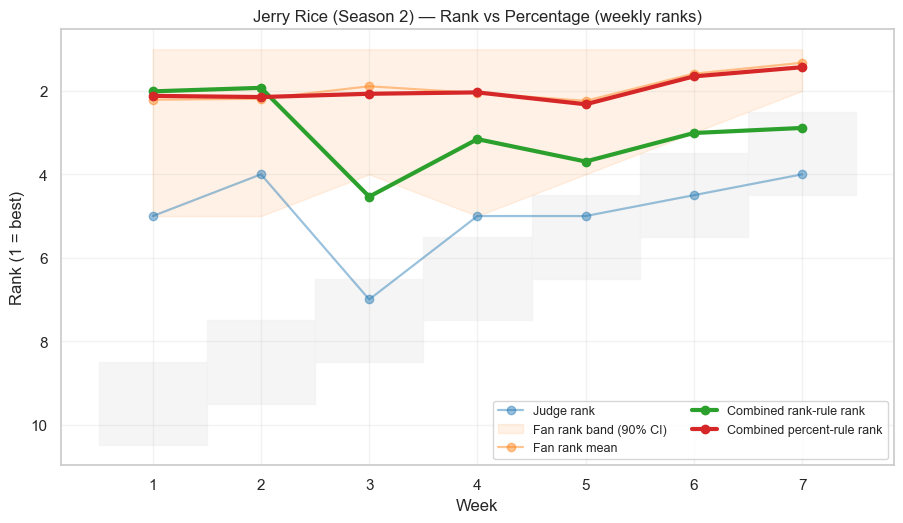

Saved: fig_rank_vs_pct_2_Jerry_Rice.png


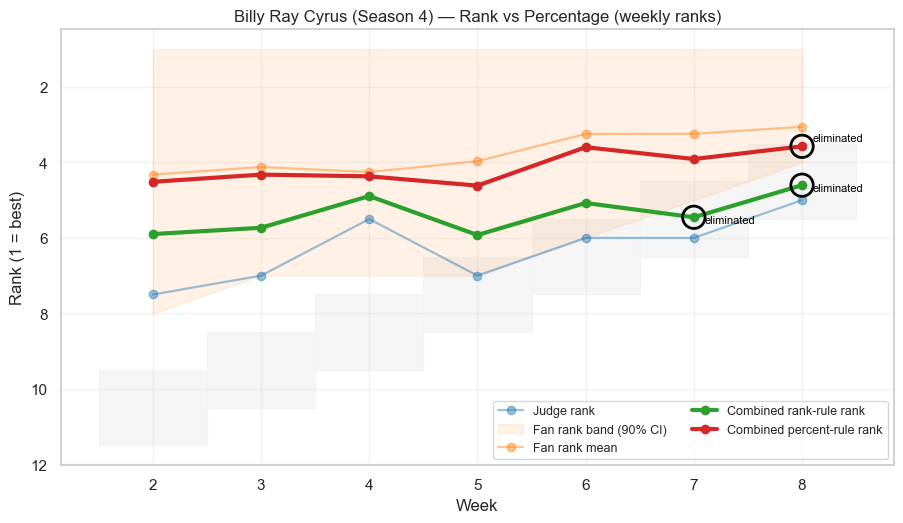

Saved: fig_rank_vs_pct_4_Billy_Ray_Cyrus.png


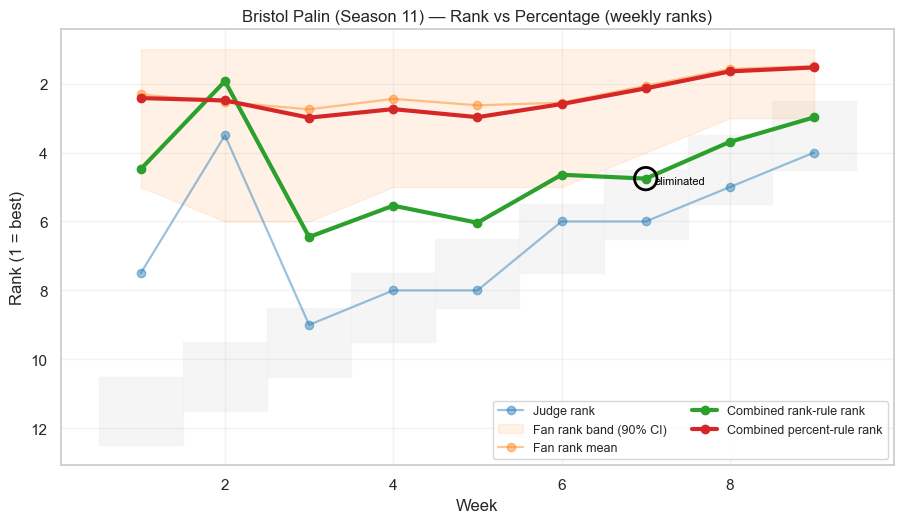

Saved: fig_rank_vs_pct_11_Bristol_Palin.png


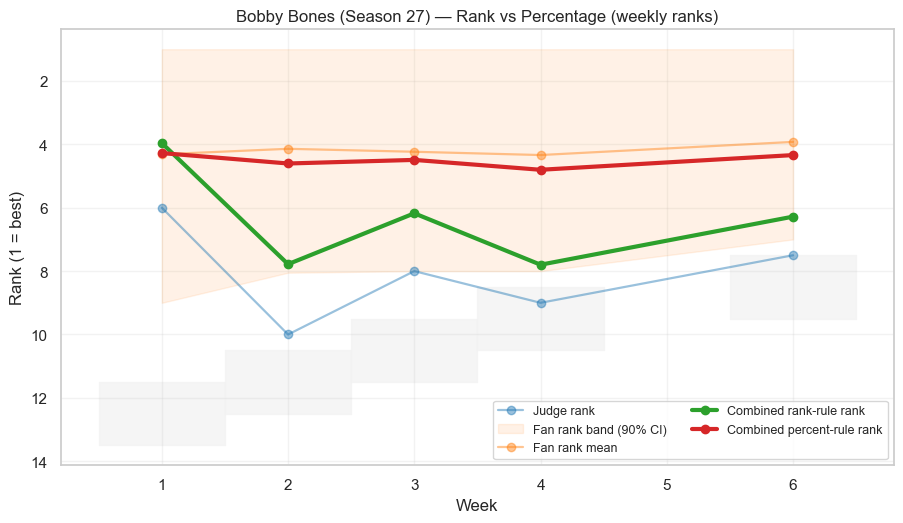

Saved: fig_rank_vs_pct_27_Bobby_Bones.png


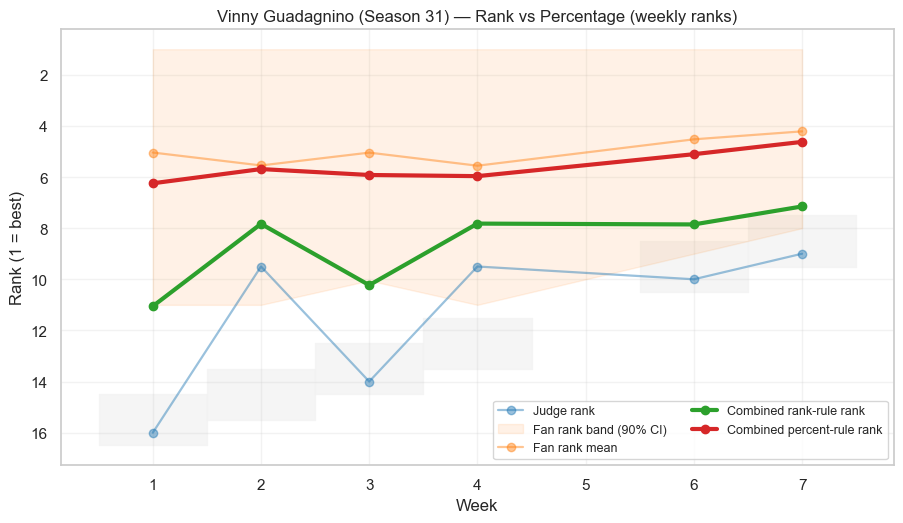

Saved: fig_rank_vs_pct_31_Vinny_Guadagnino.png


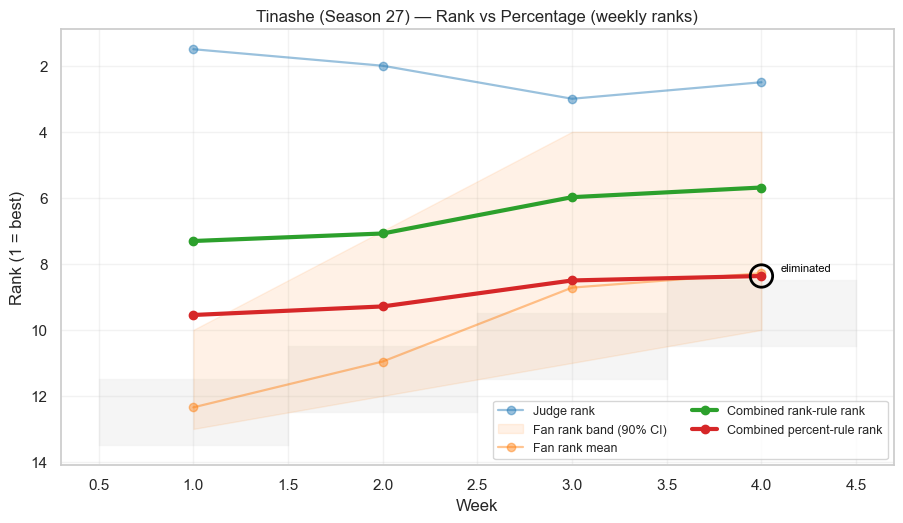

Saved: fig_rank_vs_pct_27_Tinashe.png


In [132]:
# --- Selected cases: weekly rank evolution (Rank vs Percentage) ---

# required cases (fallback if earlier cell was not run)
if 'required_cases' not in globals():
    required_cases = [
        (2, 'Jerry Rice'),
        (4, 'Billy Ray Cyrus'),
        (11, 'Bristol Palin'),
        (27, 'Bobby Bones'),
    ]

# pick 2 extra cases using disagreement + flip exposure
# always include these two
explicit_cases = [(31, 'Vinny Guadagnino'), (27, 'Tinashe')]
extras = explicit_cases.copy()

try:
    flip_week = rev_df[['season','week','rev_rate_rank_vs_pct']].copy()
    contestant_week = eligible[['season','week','celebrity_name']].drop_duplicates()
    contestant_week = contestant_week.merge(flip_week, on=['season','week'], how='left')

    flip_by_contestant = (contestant_week.groupby(['season','celebrity_name'])
                          .agg(max_flip=('rev_rate_rank_vs_pct','max'),
                               mean_flip=('rev_rate_rank_vs_pct','mean'),
                               n_weeks=('week','nunique'))
                          .reset_index())

    cand = disagree_index.copy()
    cand['abs_dr'] = cand['delta_r_bar'].abs()
    cand['abs_ds'] = cand['delta_s_bar'].abs()
    cand['abs_d'] = cand[['abs_dr','abs_ds']].max(axis=1)
    cand = cand.merge(flip_by_contestant, on=['season','celebrity_name'], how='left')
    cand['flip_ok'] = cand['max_flip'] >= 0.20

    required_set = set(required_cases)
    explicit_set = set(explicit_cases)
    cand = cand[~cand.apply(lambda r: (int(r['season']), r['celebrity_name']) in required_set, axis=1)]
    cand = cand[~cand.apply(lambda r: (int(r['season']), r['celebrity_name']) in explicit_set, axis=1)]

    pool = cand[cand['flip_ok']].copy()
    if pool.empty:
        pool = cand.copy()

    pool = pool.sort_values(['abs_d','max_flip','mean_flip','n_weeks'], ascending=False)
    if len(extras) < 2:
        for _, r in pool.head(2 - len(extras)).iterrows():
            extras.append((int(r['season']), r['celebrity_name']))
except Exception as e:
    print('Extra-case selection skipped:', e)

CASES = required_cases + extras
print('Selected cases:', CASES)

# ---- rank trace builder ----

def _rank_asc(x):
    return pd.Series(x).rank(ascending=True, method='average').to_numpy()

# You already have _rank_desc and _select_J_share defined earlier in your notebook.
# Assumed convention (consistent with your code):
# - _rank_desc(x): larger value => better (rank 1 is best), returns ranks (1..n)

def build_rank_traces(season, name, *, wJ=0.5, wF=0.5, fan_ci=(0.05, 0.95)):
    rows = []
    weeks = sorted([wk for (s, wk) in eligible_weeks if s == season])
    weeks = [wk for wk in weeks if (season, wk) in p_draws_cache]
    if not weeks:
        return pd.DataFrame()

    for wk in weeks:
        names_w, p_draws = p_draws_cache[(season, wk)]
        if name not in names_w:
            continue

        dfw = eligible[
            (eligible['season'] == season) &
            (eligible['week'] == wk) &
            (eligible['celebrity_name'].isin(names_w))
        ].copy()

        # enforce alignment with names_w
        dfw = dfw.set_index('celebrity_name').loc[names_w].reset_index()

        J_share, _ = _select_J_share(dfw)
        rJ_all = _rank_desc(J_share)
        idx = names_w.index(name)

        B = p_draws.shape[0]
        rF_list, rRank_list, rPct_list = [], [], []

        for b in range(B):
            p_b = p_draws[b]
            rF = _rank_desc(p_b)
            rF_list.append(rF[idx])

            # rank-rule: S = rJ + rF, smaller S is better
            S = rJ_all + rF
            rRank = _rank_asc(S)
            rRank_list.append(rRank[idx])

            # percent-rule: score = wJ*J + wF*p, larger is better
            score = wJ * J_share + wF * p_b
            rPct = _rank_desc(score)
            rPct_list.append(rPct[idx])

        rF_arr = np.asarray(rF_list)
        rRank_arr = np.asarray(rRank_list)
        rPct_arr = np.asarray(rPct_list)

        rows.append({
            'season': season,
            'week': wk,
            'alive_n': len(names_w),
            'rJ': float(rJ_all[idx]),
            'rF_mean': float(np.mean(rF_arr)),
            'rF_lo': float(np.quantile(rF_arr, fan_ci[0])),
            'rF_hi': float(np.quantile(rF_arr, fan_ci[1])),
            'rRank_mean': float(np.mean(rRank_arr)),
            'rPct_mean': float(np.mean(rPct_arr)),
        })

    df = pd.DataFrame(rows)
    if df.empty:
        return df

    # -----------------------------
    # Deterministic Bottom-2 + judges' save labels (computed from S)
    # Bottom2(s,t) = arg two-min_{i in A_{s,t}} S_{i,s,t}
    # Here we compute S using posterior mean fan share p_mean for that week.
    #
    # judges' save (operationalization):
    #   among the Bottom-2, eliminate the one with WORSE judge rank (larger rJ).
    # -----------------------------
    b2_rows = []
    for wk in df['week'].tolist():
        if (season, wk) not in p_draws_cache:
            continue
        names_w, p_draws = p_draws_cache[(season, wk)]
        if name not in names_w:
            continue

        dfw = eligible[
            (eligible['season'] == season) &
            (eligible['week'] == wk) &
            (eligible['celebrity_name'].isin(names_w))
        ].copy()
        dfw = dfw.set_index('celebrity_name').loc[names_w].reset_index()

        J_share, _ = _select_J_share(dfw)
        rJ_all = _rank_desc(J_share)

        p_mean = p_draws.mean(axis=0)
        me = names_w.index(name)

        # --- rank-rule S_rank = rJ + rF (rF induced by p_mean) ---
        rF_all = _rank_desc(p_mean)
        S_rank = rJ_all + rF_all  # smaller is better
        b2_idx_rank = np.argsort(S_rank)[-2:]  # two worst (largest S)
        in_b2_rank = (me in b2_idx_rank)

        if in_b2_rank:
            worst_j_idx = int(b2_idx_rank[np.argmax(rJ_all[b2_idx_rank])])  # larger rJ => worse
            elim_rank = (me == worst_j_idx)
        else:
            elim_rank = False

        # --- percent-rule S_pct = wJ*J + wF*p_mean ---
        S_pct = wJ * J_share + wF * p_mean  # larger is better
        b2_idx_pct = np.argsort(S_pct)[:2]  # two worst (smallest score)
        in_b2_pct = (me in b2_idx_pct)

        if in_b2_pct:
            worst_j_idx2 = int(b2_idx_pct[np.argmax(rJ_all[b2_idx_pct])])
            elim_pct = (me == worst_j_idx2)
        else:
            elim_pct = False

        b2_rows.append({
            'week': wk,
            'in_bottom2_rank': int(in_b2_rank),
            'elim_under_save_rank': int(elim_rank),
            'in_bottom2_pct': int(in_b2_pct),
            'elim_under_save_pct': int(elim_pct),
        })

    b2_df = pd.DataFrame(b2_rows)
    if not b2_df.empty:
        df = df.merge(b2_df, on='week', how='left')
    else:
        df['in_bottom2_rank'] = 0
        df['elim_under_save_rank'] = 0
        df['in_bottom2_pct'] = 0
        df['elim_under_save_pct'] = 0

    # fill any missing weeks with 0
    for col in ['in_bottom2_rank','elim_under_save_rank','in_bottom2_pct','elim_under_save_pct']:
        if col in df.columns:
            df[col] = df[col].fillna(0).astype(int)

    return df


def plot_rank_traces(df, season, name):
    if df.empty:
        print(f'No data for {name} (Season {season}).')
        return

    fig, ax = plt.subplots(figsize=(9.2, 5.4))

    # bottom2 region shading (week-specific): keep your original shading
    for _, r in df.iterrows():
        y1 = r['alive_n'] - 1 - 0.5
        y2 = r['alive_n'] + 0.5
        ax.fill_between([r['week']-0.5, r['week']+0.5], y1, y2,
                        color='#f2f2f2', alpha=0.7, zorder=0)

    # lines (keep original: solid circle markers; no extra encoding)
    ax.plot(df['week'], df['rJ'], color='#1f77b4', marker='o', linewidth=1.6,alpha=0.45, label='Judge rank')

    ax.fill_between(df['week'], df['rF_lo'], df['rF_hi'],
                    color='#ff7f0e', alpha=0.1, label='Fan rank band (90% CI)')
    ax.plot(df['week'], df['rF_mean'], color='#ff7f0e', marker='o', linewidth=1.6, alpha=0.45,label='Fan rank mean')

    ax.plot(df['week'], df['rRank_mean'], color='#2ca02c', marker='o', linewidth=3, label='Combined rank-rule rank')
    ax.plot(df['week'], df['rPct_mean'],  color='#d62728', marker='o', linewidth=3, label='Combined percent-rule rank')

    # -----------------------------
    # Bottom-2 annotations (deterministic)
    # Ring highlight + tiny label "eliminated"/"saved"
    # Only for combined rank-rule and combined percent-rule
    # -----------------------------
    for col in ['in_bottom2_rank','elim_under_save_rank','in_bottom2_pct','elim_under_save_pct']:
        if col not in df.columns:
            df[col] = 0

    def _annotate_bottom2(x_weeks, y_vals, in_b2, elim_flag, *, y_offset=0.0):
        for wk, y, b2, elim in zip(x_weeks, y_vals, in_b2, elim_flag):
            if not b2:
                continue
            # ring highlight around the existing point (does not change the line marker)
            ax.scatter([wk], [y], s=260, facecolors='none',
                       edgecolors='black', linewidths=2.0, zorder=8)
            ax.text(wk + 0.10, y + y_offset,
                    'eliminated' if elim else 'saved',
                    fontsize=8, color='black', zorder=9)

    _annotate_bottom2(
        df['week'].to_numpy(),
        df['rRank_mean'].to_numpy(),
        df['in_bottom2_rank'].astype(int).to_numpy(),
        df['elim_under_save_rank'].astype(int).to_numpy(),
        y_offset=+0.15
    )

    _annotate_bottom2(
        df['week'].to_numpy(),
        df['rPct_mean'].to_numpy(),
        df['in_bottom2_pct'].astype(int).to_numpy(),
        df['elim_under_save_pct'].astype(int).to_numpy(),
        y_offset=-0.15
    )

    ax.set_title(f'{name} (Season {season}) — Rank vs Percentage (weekly ranks)')
    ax.set_xlabel('Week')
    ax.set_ylabel('Rank (1 = best)')
    ax.invert_yaxis()
    ax.grid(alpha=0.25)
    ax.legend(loc='lower right', ncol=2, fontsize=9)

    plt.tight_layout()
    out = f"fig_rank_vs_pct_{season}_{name.replace(' ', '_')}.png"
    plt.savefig(out, dpi=300)
    plt.show()
    print('Saved:', out)


# ---- render cases ----
for season, name in CASES:
    df_case = build_rank_traces(season, name, wJ=0.5, wF=0.5)
    plot_rank_traces(df_case, season, name)


In [133]:
# --- Bottom-2 + judges' save contestant-level diagnostics (rank/pct) ---
import numpy as np
import pandas as pd


def get_Tmax_by_season(panel):
    return panel.groupby("season")["week"].max().to_dict()


def _infer_alive_flags(panel):
    df = panel.copy()

    if "alive" not in df.columns:
        df["alive"] = True

    # finale flag
    if "is_final_week" in df.columns:
        df["is_finale"] = df["is_final_week"].astype(bool)
    elif "is_finale" in df.columns:
        df["is_finale"] = df["is_finale"].astype(bool)
    elif "is_final_week_end" in df.columns:
        df["is_finale"] = df["is_final_week_end"].astype(bool)
    else:
        df["is_finale"] = False

    # single-elimination flag
    if "elim_this_week_end" in df.columns:
        g = (
            df.groupby(["season", "week"])["elim_this_week_end"]
            .sum()
            .reset_index(name="elim_cnt")
        )
        df = df.merge(g, on=["season", "week"], how="left")
        df["is_single_elim_week"] = df["elim_cnt"] == 1
    elif "is_single_elim_week" in df.columns:
        df["is_single_elim_week"] = df["is_single_elim_week"].astype(bool)
    else:
        df["is_single_elim_week"] = True

    return df


def eligible_week_selector(df_week):
    if "is_finale" in df_week.columns and bool(df_week["is_finale"].iloc[0]):
        return False
    if "is_single_elim_week" in df_week.columns and not bool(df_week["is_single_elim_week"].iloc[0]):
        return False
    if "alive" in df_week.columns:
        return df_week["alive"].sum() > 2
    return True


def get_week_draws(posterior_draws, season, week, names):
    key = (int(season), int(week))

    # case 1: dict keyed by (season, week)
    if isinstance(posterior_draws, dict) and key in posterior_draws:
        val = posterior_draws[key]

        if isinstance(val, dict) and "p_draws" in val and "names" in val:
            p = val["p_draws"]
            draw_names = list(val["names"])
        elif isinstance(val, (list, tuple)) and len(val) == 2:
            p, draw_names = val
            draw_names = list(draw_names)
        else:
            p, draw_names = val, list(names)

        # align to current names order
        if list(draw_names) != list(names):
            idx = {n: i for i, n in enumerate(draw_names)}
            cols = [idx[n] for n in names if n in idx]
            p = p[:, cols]
            names = [n for n in names if n in idx]
        return p, names

    # case 2: long-form dataframe
    if isinstance(posterior_draws, pd.DataFrame):
        required = {"season", "week", "celebrity_name", "b", "p_draw"}
        if required.issubset(posterior_draws.columns):
            g = posterior_draws[
                (posterior_draws["season"] == season) & (posterior_draws["week"] == week)
            ]
            if g.empty:
                return None, None

            order = pd.Index(names)
            g = g.copy()
            g["celebrity_name"] = pd.Categorical(
                g["celebrity_name"], categories=order, ordered=True
            )
            g = g.sort_values(["b", "celebrity_name"])
            p = g.pivot_table(index="b", columns="celebrity_name", values="p_draw")
            p = p.reindex(columns=order)
            return p.to_numpy(), list(p.columns)

    return None, None


def _rank_desc(x):
    return pd.Series(x).rank(ascending=False, method="average").to_numpy()


def _get_judge_score_cols(df):
    for col in ["total_judge_score", "judge_total", "j_metric", "judge_score", "score_judge"]:
        if col in df.columns:
            return col
    return None

def _align_df_to_names(df, names):
    order = pd.Index(names)
    d = df.copy()
    d['celebrity_name'] = pd.Categorical(d['celebrity_name'], categories=order, ordered=True)
    d = d.sort_values('celebrity_name')
    return d

def _vec_from_col(df, names, col):
    m = df.set_index('celebrity_name')[col]
    return m.reindex(names).to_numpy(float)




def compute_risk_and_bottom2(p_draw, names, judge_pct, judge_rank, baseline_mode, wJ=0.5, wF=0.5):
    names = np.asarray(names)

    # risk: larger = worse
    if baseline_mode == "pct":
        risk = wJ * (1.0 - judge_pct) + wF * (1.0 - p_draw)
    else:
        fan_rank = _rank_desc(p_draw)
        risk = wJ * judge_rank + wF * fan_rank

    # stable tie-breaks: risk desc, then judge_pct/p_draw/name to stabilize
    name_key = np.argsort(names)  # deterministic tie-break key
    order = np.lexsort((name_key, p_draw, judge_pct, -risk))  # bottom is order[:2]
    bottom2_idx = order[:2]
    bottom2 = list(names[bottom2_idx])

    # baseline elimination: worst risk
    elim_base = names[order[0]]

    # judge save within bottom2: eliminate worse judge signal
    if baseline_mode == "pct":
        judge_signal = judge_pct
    else:
        judge_signal = -judge_rank  # higher is better

    b2_j = judge_signal[bottom2_idx]
    b2_p = p_draw[bottom2_idx]
    b2_names = names[bottom2_idx]

    # eliminate smaller judge signal; tie-break by lower fan share; then name
    elim_local = np.lexsort((np.argsort(b2_names), b2_p, b2_j))[0]
    elim_idx = bottom2_idx[elim_local]
    elim_save = names[elim_idx]

    return risk, bottom2, elim_base, elim_save


def simulate_season_for_draw(season, panel, posterior_draws, baseline_mode, wJ=0.5, wF=0.5, eligible_selector=eligible_week_selector):
    """
    NOTE: 你原本这里把 alive 同时 discard elim_base 和 elim_save，会混合两条路径。
    我这里只修“缩进与可运行性”，不改你想要的模拟结构。
    """
    df = panel[panel["season"] == season].copy()
    Tmax = df["week"].max()

    weeks = []
    for wk, g in df.groupby("week"):
        if wk >= Tmax:
            continue
        if eligible_selector(g):
            weeks.append(wk)
    weeks = sorted(weeks)

    alive = set(
        df[(df["week"] == weeks[0]) & (df["alive"] == True)]["celebrity_name"].tolist()
    ) if weeks else set()

    t_elim_base = {n: np.inf for n in alive}
    t_elim_save = {n: np.inf for n in alive}

    for wk in weeks:
        g = df[(df["week"] == wk) & (df["celebrity_name"].isin(alive))].copy()
        if g.empty or len(g["celebrity_name"].unique()) < 3:
            continue

        names = g["celebrity_name"].tolist()
        p_draws, aligned_names = get_week_draws(posterior_draws, season, wk, names)
        if p_draws is None:
            continue

        if aligned_names != names:
            names = aligned_names
            g = g[g["celebrity_name"].isin(names)].copy()

        # judge signals
        if baseline_mode == "pct":
            if "judge_pct" in g.columns:
                judge_pct = _vec_from_col(g, names, "judge_pct")
            elif "judge_share" in g.columns:
                judge_pct = _vec_from_col(g, names, "judge_share")
            else:
                score_col = _get_judge_score_cols(g)
                if score_col is None:
                    raise KeyError(
                        "No judge score column found. Expected one of: "
                        "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                    )
                v = _vec_from_col(g, names, score_col)
                judge_pct = v / v.sum() if v.sum() != 0 else np.zeros_like(v)

            judge_rank = _rank_desc(judge_pct)

        else:
            if "judge_rank" in g.columns:
                judge_rank = _vec_from_col(g, names, "judge_rank")
            else:
                score_col = _get_judge_score_cols(g)
                if score_col is None:
                    raise KeyError(
                        "No judge score column found. Expected one of: "
                        "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                    )
                judge_rank = _rank_desc(_vec_from_col(g, names, score_col))

            judge_pct = 1.0 - (judge_rank - 1.0) / max(len(judge_rank) - 1, 1)

        # iterate draws
        for b in range(p_draws.shape[0]):
            p_b = p_draws[b]
            _, _, elim_base, elim_save = compute_risk_and_bottom2(
                p_b, names, judge_pct, judge_rank, baseline_mode, wJ=wJ, wF=wF
            )

            if np.isinf(t_elim_base.get(elim_base, np.inf)):
                t_elim_base[elim_base] = wk
            if np.isinf(t_elim_save.get(elim_save, np.inf)):
                t_elim_save[elim_save] = wk

        # your original “alive update” logic kept as-is
        alive.discard(elim_base)
        alive.discard(elim_save)

    return t_elim_base, t_elim_save, Tmax


def compute_b2_save_metrics(
    selected_pairs,
    panel,
    posterior_draws,
    baseline_modes=("rank", "pct"),
    wJ=0.5,
    wF=0.5,
    contestant_types=None,
    bootstrap=False,
    n_boot=1000,
):
    df = _infer_alive_flags(panel)
    Tmax_by_season = get_Tmax_by_season(df)

    rows = []

    for baseline_mode in baseline_modes:
        for season, name in selected_pairs:
            season = int(season)
            Tmax = Tmax_by_season.get(season)
            if Tmax is None:
                continue

            weeks = sorted([wk for wk in df[df["season"] == season]["week"].unique() if wk < Tmax])
            weeks = [wk for wk in weeks if eligible_week_selector(df[(df["season"] == season) & (df["week"] == wk)])]

            # per-week/draw tallies
            p_b2_hits = 0
            p_rev_given_b2_hits = 0
            p_rev_hits = 0
            denom_b2 = 0
            T_i = 0
            B = None

            for wk in weeks:
                g = df[(df["season"] == season) & (df["week"] == wk) & (df["alive"] == True)].copy()
                if g.empty:
                    continue

                names = g["celebrity_name"].tolist()
                if name not in names:
                    continue

                p_draws, aligned_names = get_week_draws(posterior_draws, season, wk, names)
                if p_draws is None:
                    continue

                if aligned_names != names:
                    names = aligned_names
                    g = g[g["celebrity_name"].isin(names)].copy()
                    if name not in names:
                        continue

                # judge signals
                if baseline_mode == "pct":
                    if "judge_pct" in g.columns:
                        judge_pct = _vec_from_col(g, names, "judge_pct")
                    elif "judge_share" in g.columns:
                        judge_pct = _vec_from_col(g, names, "judge_share")
                    else:
                        score_col = _get_judge_score_cols(g)
                        if score_col is None:
                            raise KeyError(
                                "No judge score column found. Expected one of: "
                                "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                            )
                        v = _vec_from_col(g, names, score_col)
                        judge_pct = v / v.sum() if v.sum() != 0 else np.zeros_like(v)

                    judge_rank = _rank_desc(judge_pct)

                else:
                    if "judge_rank" in g.columns:
                        judge_rank = _vec_from_col(g, names, "judge_rank")
                    else:
                        score_col = _get_judge_score_cols(g)
                        if score_col is None:
                            raise KeyError(
                                "No judge score column found. Expected one of: "
                                "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                            )
                        judge_rank = _rank_desc(_vec_from_col(g, names, score_col))

                    judge_pct = 1.0 - (judge_rank - 1.0) / max(len(judge_rank) - 1, 1)

                B = p_draws.shape[0]
                for b in range(B):
                    p_b = p_draws[b]
                    if len(names) < 2 or p_b is None or len(p_b) == 0:
                        continue
                    _, bottom2, elim_base, elim_save = compute_risk_and_bottom2(
                        p_b, names, judge_pct, judge_rank, baseline_mode, wJ=wJ, wF=wF
                    )
                    if name in bottom2:
                        p_b2_hits += 1
                        denom_b2 += 1
                        if elim_base != elim_save:
                            p_rev_given_b2_hits += 1
                    if elim_base != elim_save:
                        p_rev_hits += 1

                T_i += 1

            if T_i == 0 or B is None:
                continue

            p_b2 = p_b2_hits / (T_i * B)
            p_rev = p_rev_hits / (T_i * B)
            p_rev_given_b2 = (p_rev_given_b2_hits / denom_b2) if denom_b2 > 0 else np.nan

            # --- season-level per-draw simulation for elimination week of target ---
            weeks_sim = weeks
            if not weeks_sim:
                continue

            alive0 = set(
                df[(df["season"] == season) & (df["week"] == weeks_sim[0]) & (df["alive"] == True)]["celebrity_name"].tolist()
            )

            p0, names0 = get_week_draws(posterior_draws, season, weeks_sim[0], list(alive0))
            if p0 is None:
                continue
            B = p0.shape[0]

            t_base_draws = []
            t_save_draws = []

            for b in range(B):
                alive_base = set(alive0)
                alive_save = set(alive0)
                t_base = Tmax
                t_save = Tmax

                for wk in weeks_sim:
                    # --- base path ---
                    g_base = df[(df["season"] == season) & (df["week"] == wk) & (df["celebrity_name"].isin(alive_base))].copy()
                    if len(g_base) >= 3:
                        names = g_base["celebrity_name"].tolist()
                        p_draws, aligned_names = get_week_draws(posterior_draws, season, wk, names)
                        if p_draws is not None:
                            names = aligned_names
                            p_b = p_draws[b]

                            if baseline_mode == "pct":
                                if "judge_pct" in g_base.columns:
                                    judge_pct = _vec_from_col(g_base, names, "judge_pct")
                                elif "judge_share" in g_base.columns:
                                    judge_pct = _vec_from_col(g_base, names, "judge_share")
                                else:
                                    score_col = _get_judge_score_cols(g_base)
                                    if score_col is None:
                                        raise KeyError(
                                            "No judge score column found. Expected one of: "
                                            "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                                        )
                                    v = _vec_from_col(g_base, names, score_col)
                                    judge_pct = v / v.sum() if v.sum() != 0 else np.zeros_like(v)
                                judge_rank = _rank_desc(judge_pct)
                            else:
                                if "judge_rank" in g_base.columns:
                                    judge_rank = _vec_from_col(g_base, names, "judge_rank")
                                else:
                                    score_col = _get_judge_score_cols(g_base)
                                    if score_col is None:
                                        raise KeyError(
                                            "No judge score column found. Expected one of: "
                                            "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                                        )
                                    judge_rank = _rank_desc(_vec_from_col(g_base, names, score_col))
                                judge_pct = 1.0 - (judge_rank - 1.0) / max(len(judge_rank) - 1, 1)

                            _, _, elim_base, _ = compute_risk_and_bottom2(
                                p_b, names, judge_pct, judge_rank, baseline_mode, wJ=wJ, wF=wF
                            )
                            if name in alive_base and elim_base == name and t_base == Tmax:
                                t_base = wk
                            alive_base.discard(elim_base)

                    # --- save path ---
                    g_save = df[(df["season"] == season) & (df["week"] == wk) & (df["celebrity_name"].isin(alive_save))].copy()
                    if len(g_save) >= 3:
                        names = g_save["celebrity_name"].tolist()
                        p_draws, aligned_names = get_week_draws(posterior_draws, season, wk, names)
                        if p_draws is not None:
                            names = aligned_names
                            p_b = p_draws[b]

                            if baseline_mode == "pct":
                                if "judge_pct" in g_save.columns:
                                    judge_pct = _vec_from_col(g_save, names, "judge_pct")
                                elif "judge_share" in g_save.columns:
                                    judge_pct = _vec_from_col(g_save, names, "judge_share")
                                else:
                                    score_col = _get_judge_score_cols(g_save)
                                    if score_col is None:
                                        raise KeyError(
                                            "No judge score column found. Expected one of: "
                                            "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                                        )
                                    v = _vec_from_col(g_save, names, score_col)
                                    judge_pct = v / v.sum() if v.sum() != 0 else np.zeros_like(v)
                                judge_rank = _rank_desc(judge_pct)
                            else:
                                if "judge_rank" in g_save.columns:
                                    judge_rank = _vec_from_col(g_save, names, "judge_rank")
                                else:
                                    score_col = _get_judge_score_cols(g_save)
                                    if score_col is None:
                                        raise KeyError(
                                            "No judge score column found. Expected one of: "
                                            "total_judge_score, judge_total, j_metric, judge_score, score_judge"
                                        )
                                    judge_rank = _rank_desc(_vec_from_col(g_save, names, score_col))
                                judge_pct = 1.0 - (judge_rank - 1.0) / max(len(judge_rank) - 1, 1)

                            _, _, _, elim_save = compute_risk_and_bottom2(
                                p_b, names, judge_pct, judge_rank, baseline_mode, wJ=wJ, wF=wF
                            )
                            if name in alive_save and elim_save == name and t_save == Tmax:
                                t_save = wk
                            alive_save.discard(elim_save)

                t_base_draws.append(t_base)
                t_save_draws.append(t_save)

            t_base_draws = np.asarray(t_base_draws)
            t_save_draws = np.asarray(t_save_draws)

            dE_T = float(np.mean(t_save_draws) - np.mean(t_base_draws))
            dP_finals = float(np.mean(t_save_draws == Tmax) - np.mean(t_base_draws == Tmax))

            rows.append(
                {
                    "season": season,
                    "celebrity_name": name,
                    "baseline_mode": baseline_mode,
                    "p_b2": p_b2,
                    "p_rev_given_b2": p_rev_given_b2,
                    "p_rev": p_rev,
                    "dE_T": dE_T,
                    "dP_finals": dP_finals,
                    "n_weeks": int(T_i),
                    "B": int(B),
                    "denom_b2": int(denom_b2),
                    "Tmax": int(Tmax),
                    "unit_type": "individual",
                    "unit_id": name,
                }
            )

    out = pd.DataFrame(rows)

    # group-level aggregation
    if contestant_types is not None and not out.empty:
        type_df = contestant_types.copy()
        type_df["season"] = type_df["season"].astype(int)

        merged = out.merge(type_df, on=["season", "celebrity_name"], how="left")

        group_rows = []
        metrics = ["p_b2", "p_rev_given_b2", "p_rev", "dE_T", "dP_finals"]

        for baseline_mode in baseline_modes:
            g0 = merged[merged["baseline_mode"] == baseline_mode]
            for t, g in g0.groupby("contestant_type"):
                row = {
                    "season": np.nan,
                    "celebrity_name": np.nan,
                    "baseline_mode": baseline_mode,
                    "unit_type": "group",
                    "unit_id": t,
                    "n_units": int(len(g)),
                }

                for m in metrics:
                    row[f"{m}_mean"] = float(np.nanmean(g[m])) if len(g) else np.nan
                    row[f"{m}_median"] = float(np.nanmedian(g[m])) if len(g) else np.nan

                if bootstrap and len(g) > 1:
                    rng = np.random.default_rng(42)
                    vals_dict = {m: g[m].to_numpy() for m in metrics}

                    for m in metrics:
                        vals = vals_dict[m]
                        boots = []
                        for _ in range(n_boot):
                            samp = rng.choice(vals, size=len(vals), replace=True)
                            boots.append(np.nanmean(samp))
                        lo, hi = np.nanquantile(boots, [0.025, 0.975])
                        row[f"{m}_mean_lo"] = float(lo)
                        row[f"{m}_mean_hi"] = float(hi)

                group_rows.append(row)

        out = pd.concat([out, pd.DataFrame(group_rows)], ignore_index=True)

    return out






In [136]:
# 6 个争议选手（示例，按你的实际列表替换）
selected_pairs = [
    (27, "Bobby Bones"),
    (11, "Bristol Palin"),
    (4, "Billy Ray Cyrus"),
    (2, "Jerry Rice"),
    (27, "Tinashe"),
    (31, "Vinny Guadagnino"),
]

# contestant_types 需要包含 season, celebrity_name, contestant_type 三列
# 例如：contestant_types = df_types[['season','celebrity_name','contestant_type']]

metrics_df = compute_b2_save_metrics(
    selected_pairs=selected_pairs,
    panel=panel,                 # 或 df_weekly/df_weekly2，只要含 season/week/celebrity_name/alive/评委信号
    posterior_draws=post_draws,  # dict 或 long df
    baseline_modes=("rank","pct"),
    wJ=0.5, wF=0.5,
    #contestant_types=contestant_types,  # 可选
    bootstrap=False               # 需要CI就 True
)

metrics_df.head()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [135]:
# --- Define contestant_types by technical / fan-driven / balanced rules ---
import numpy as np
import pandas as pd

if 'disagree_index' not in globals():
    raise KeyError('Need disagree_index with delta_r_bar, delta_s_bar, pi_r, pi_s')

# thresholds
if 'c_r' not in globals() or 'c_s' not in globals():
    raise KeyError('Need c_r and c_s thresholds (from Scheme A cell)')
if 'tau' not in globals():
    tau = 0.5

ct = disagree_index[['season','celebrity_name','delta_r_bar','delta_s_bar','pi_r','pi_s']].copy()
ct['max_pi'] = ct[['pi_r','pi_s']].max(axis=1)

judge_driven = (ct['delta_r_bar'] >= c_r) & (ct['delta_s_bar'] <= -c_s) & (ct['max_pi'] >= tau)
fan_driven = (ct['delta_r_bar'] <= -c_r) & (ct['delta_s_bar'] >= c_s) & (ct['max_pi'] >= tau)
balanced = (ct['delta_r_bar'].abs() < c_r) & (ct['delta_s_bar'].abs() < c_s) & (ct['max_pi'] < tau)

ct['contestant_type'] = 'balanced'
ct.loc[judge_driven, 'contestant_type'] = 'judge-driven'
ct.loc[fan_driven, 'contestant_type'] = 'fan-driven'
ct.loc[balanced, 'contestant_type'] = 'balanced'

contestant_types = ct[['season','celebrity_name','contestant_type']].copy()
contestant_types.head()


,season,celebrity_name,contestant_type
0,1,Evander Holyfield,balanced
1,1,Joey McIntyre,balanced
2,1,John O'Hurley,balanced
3,1,Kelly Monaco,balanced
4,1,Rachel Hunter,balanced


In [137]:
from b2_save_metrics import compute_b2_save_metrics


In [138]:
metrics_df = compute_b2_save_metrics(
    selected_pairs=selected_pairs,
    panel=panel,
    posterior_draws=post_draws,
    baseline_modes=("rank","pct"),
    wJ=0.5, wF=0.5,
    contestant_types=contestant_types,  # 有就传
    bootstrap=False
)


In [139]:
metrics_df

,season,celebrity_name,baseline_mode,p_b2,p_rev_given_b2,p_rev,dE_T,dP_finals,n_weeks,B,...,p_b2_mean,p_b2_median,p_rev_given_b2_mean,p_rev_given_b2_median,p_rev_mean,p_rev_median,dE_T_mean,dE_T_median,dP_finals_mean,dP_finals_median
0,27.0,Bobby Bones,rank,0.208333,0.337600,0.352333,-1.178333,-0.275000,5.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,11.0,Bristol Palin,rank,0.402593,0.397884,0.211481,-0.941667,-0.006667,9.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,Billy Ray Cyrus,rank,0.415476,0.206304,0.245714,-0.506667,-0.005000,7.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,Jerry Rice,rank,0.287619,0.142384,0.256429,-2.136667,-0.040000,7.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,27.0,Tinashe,rank,0.003333,0.000000,0.352917,0.025000,0.005000,4.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,31.0,Vinny Guadagnino,rank,0.179167,0.631008,0.211667,-1.880000,-0.328333,6.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,27.0,Bobby Bones,pct,0.089333,0.559701,0.412667,-0.700000,-0.150000,5.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,11.0,Bristol Palin,pct,0.160000,0.697917,0.372963,-0.946667,-0.170000,9.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,4.0,Billy Ray Cyrus,pct,0.343810,0.421053,0.448810,-0.790000,-0.070000,7.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,2.0,Jerry Rice,pct,0.165476,0.343885,0.389762,-1.040000,-0.221667,7.0,600.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [140]:
metrics_df.to_csv("metrics_b2_save.csv", index=False)


In [141]:
metrics_df[metrics_df["unit_type"]=="group"]

,season,celebrity_name,baseline_mode,p_b2,p_rev_given_b2,p_rev,dE_T,dP_finals,n_weeks,B,...,p_b2_mean,p_b2_median,p_rev_given_b2_mean,p_rev_given_b2_median,p_rev_mean,p_rev_median,dE_T_mean,dE_T_median,dP_finals_mean,dP_finals_median
12,NaN,NaN,rank,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.249420,0.247976,0.285863,0.271952,0.271757,0.251071,-1.103056,-1.060000,-0.108333,-0.023333
13,NaN,NaN,pct,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.201622,0.162738,0.503663,0.499711,0.356510,0.395089,-0.203333,-0.868333,-0.040556,-0.160000
